In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/sample_data/atm_cashout_ieee_ncrp_benchmark.csv")
df.head()
df.shape
df.columns
df.isnull().sum()
df.duplicated().sum()
df.info()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 50000 non-null  object 
 1   amount                    50000 non-null  float64
 2   victim_city               50000 non-null  object 
 3   mule_latitude             50000 non-null  float64
 4   mule_longitude            50000 non-null  float64
 5   atm_latitude              50000 non-null  float64
 6   atm_longitude             50000 non-null  float64
 7   distance_to_atm_km        50000 non-null  float64
 8   transaction_velocity      50000 non-null  float64
 9   historical_hotspot_score  50000 non-null  float64
 10  cashout_atm_label         50000 non-null  int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 4.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   

In [ ]:
df.info()
df["cashout_atm_label"].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   timestamp                 50000 non-null  datetime64[ns]
 1   amount                    50000 non-null  float64       
 2   victim_city               50000 non-null  object        
 3   mule_latitude             50000 non-null  float64       
 4   mule_longitude            50000 non-null  float64       
 5   atm_latitude              50000 non-null  float64       
 6   atm_longitude             50000 non-null  float64       
 7   distance_to_atm_km        50000 non-null  float64       
 8   transaction_velocity      50000 non-null  float64       
 9   historical_hotspot_score  50000 non-null  float64       
 10  cashout_atm_label         50000 non-null  int64         
dtypes: datetime64[ns](1), float64(8), int64(1), object(1)
memory usage: 4.2+ MB


array([1, 0])

In [ ]:
print(df["mule_latitude"].between(-90, 90).all())
print(df["mule_longitude"].between(-180, 180).all())

print(df["atm_latitude"].between(-90, 90).all())
print(df["atm_longitude"].between(-180, 180).all())

True
True
True
True


In [ ]:
print("Negative amount:", (df["amount"] < 0).sum())
print("Negative distance:", (df["distance_to_atm_km"] < 0).sum())
print("Negative velocity:", (df["transaction_velocity"] < 0).sum())
print("Negative hotspot score:", (df["historical_hotspot_score"] < 0).sum())

Negative amount: 0
Negative distance: 0
Negative velocity: 0
Negative hotspot score: 0


In [ ]:
df["historical_hotspot_score"].min()

0.0034

In [ ]:
df["historical_hotspot_score"].max()

0.9837

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.describe()

,timestamp,amount,mule_latitude,mule_longitude,atm_latitude,atm_longitude,distance_to_atm_km,transaction_velocity,historical_hotspot_score,cashout_atm_label
count,50000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2026-08-11 10:05:31.924720128,4.910897e+04,22.650138,77.849440,22.650098,77.849455,1.909211,2.689117,0.400237,0.455700
min,2026-07-27 09:27:17,1.000000e+03,12.826512,72.730458,12.804859,72.719267,0.100000,0.200000,0.003400,0.000000
25%,2026-08-03 22:41:20.750000128,1.275288e+04,17.415642,74.904423,17.418948,74.908552,0.622000,0.920000,0.241900,0.000000
50%,2026-08-11 09:25:20.500000,2.695471e+04,22.598713,77.221024,22.600432,77.222060,1.357000,1.930000,0.386100,0.000000
75%,2026-08-18 22:52:11,5.665675e+04,28.584828,78.424944,28.583369,78.420067,2.605000,3.660000,0.543500,1.000000
max,2026-08-26 09:23:02,2.500000e+06,32.851601,88.522975,32.872421,88.519131,16.884000,27.550000,0.983700,1.000000
std,NaN,7.370454e+04,6.293481,4.265992,6.293489,4.266142,1.810728,2.479037,0.200799,0.498039


The dataset contains 50,000 observations with significant variation in transaction amount, ATM distance, and transaction velocity. The historical hotspot score ranges approximately between 0 and 1, indicating a normalized risk-related score. The target variable cashout_atm_label is binary and will be further analyzed for class distribution.

In [ ]:
df["cashout_atm_label"].value_counts()

,count
cashout_atm_label,
0,27215
1,22785


In [ ]:
df["cashout_atm_label"].value_counts(normalize=True)*100

,proportion
cashout_atm_label,
0,54.43
1,45.57


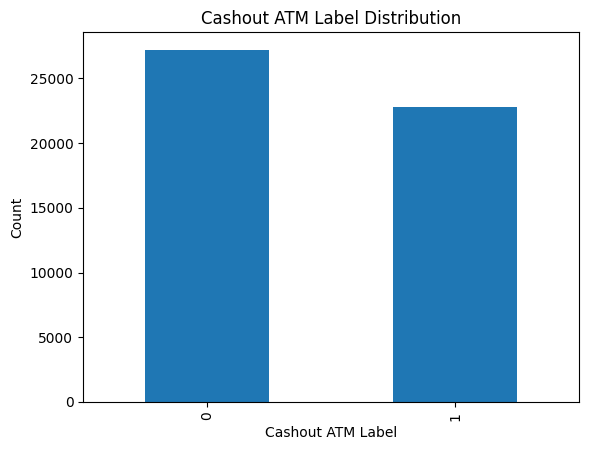

In [ ]:
import matplotlib.pyplot as plt

df["cashout_atm_label"].value_counts().plot(kind="bar")

plt.title("Cashout ATM Label Distribution")
plt.xlabel("Cashout ATM Label")
plt.ylabel("Count")

plt.show()

The target variable cashout_atm_label shows a relatively balanced class distribution. Class 0 contains 27,215 observations (54.43%), while Class 1 contains 22,785 observations (45.57%). Therefore, the dataset does not exhibit severe class imbalance.

In [ ]:
df["amount"].describe()

,amount
count,5.000000e+04
mean,4.910897e+04
std,7.370454e+04
min,1.000000e+03
25%,1.275288e+04
50%,2.695471e+04
75%,5.665675e+04
max,2.500000e+06


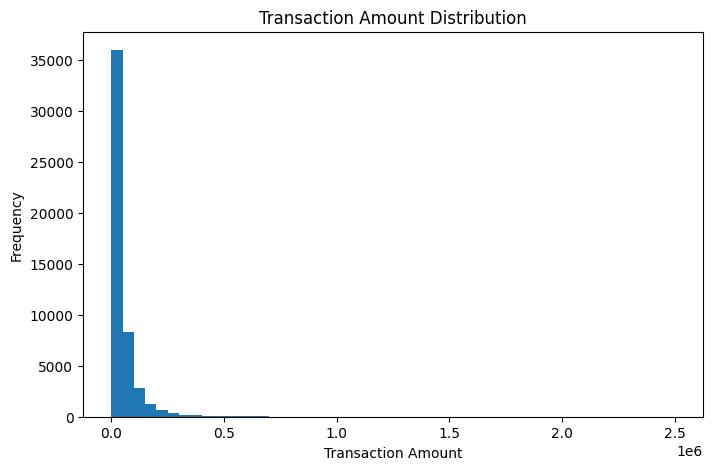

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

The transaction amount distribution is highly right-skewed. Most transactions occur at lower amount ranges, while a relatively small number of transactions have significantly higher values, extending up to approximately 2.5 million. These high-value observations will be retained because they may contain useful information for ATM cash-out hotspot prediction.

In [ ]:
df["transaction_velocity"].describe()

,transaction_velocity
count,50000.000000
mean,2.689117
std,2.479037
min,0.200000
25%,0.920000
50%,1.930000
75%,3.660000
max,27.550000


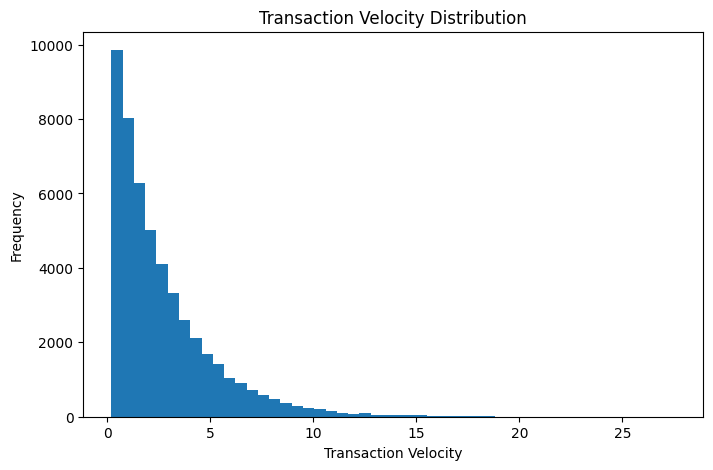

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["transaction_velocity"], bins=50)

plt.title("Transaction Velocity Distribution")
plt.xlabel("Transaction Velocity")
plt.ylabel("Frequency")

plt.show()

The transaction velocity feature exhibits a right-skewed distribution. Most observations are concentrated at lower velocity values, with a small number of observations extending to significantly higher values. The maximum transaction velocity is approximately 27.65, indicating the presence of high-velocity transactions. These observations will be retained as they may provide useful predictive information for ATM hotspot prediction.

In [ ]:
df["distance_to_atm_km"].describe()

,distance_to_atm_km
count,50000.000000
mean,1.909211
std,1.810728
min,0.100000
25%,0.622000
50%,1.357000
75%,2.605000
max,16.884000


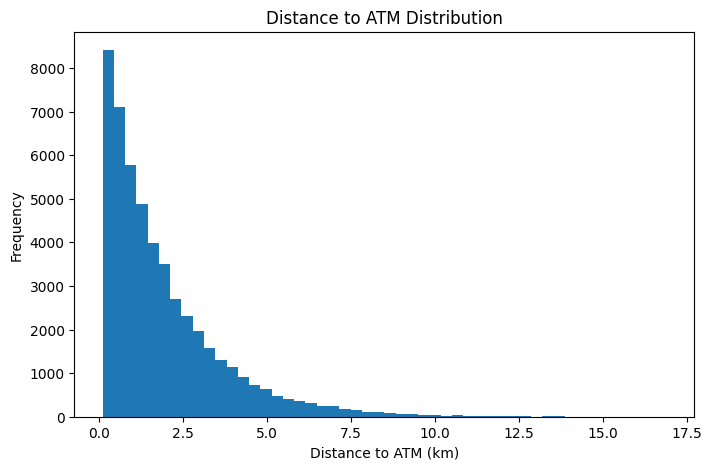

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["distance_to_atm_km"], bins=50)

plt.title("Distance to ATM Distribution")
plt.xlabel("Distance to ATM (km)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
df["historical_hotspot_score"].describe()

,historical_hotspot_score
count,50000.000000
mean,0.400237
std,0.200799
min,0.003400
25%,0.241900
50%,0.386100
75%,0.543500
max,0.983700


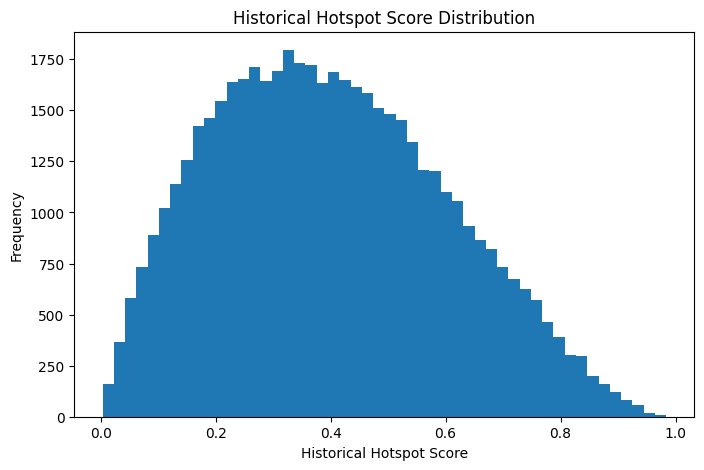

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["historical_hotspot_score"], bins=50)

plt.title("Historical Hotspot Score Distribution")
plt.xlabel("Historical Hotspot Score")
plt.ylabel("Frequency")

plt.show()

In [ ]:
df.columns.tolist()

['timestamp',
 'amount',
 'victim_city',
 'mule_latitude',
 'mule_longitude',
 'atm_latitude',
 'atm_longitude',
 'distance_to_atm_km',
 'transaction_velocity',
 'historical_hotspot_score',
 'cashout_atm_label']

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

print(df["timestamp"].head())
print(df["timestamp"].dtype)

0   2026-08-22 14:13:55
1   2026-08-14 13:22:56
2   2026-08-23 04:25:04
3   2026-08-20 09:08:20
4   2026-08-11 15:31:38
Name: timestamp, dtype: datetime64[ns]
datetime64[ns]


In [ ]:
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["day_of_week"] = df["timestamp"].dt.day_name()

df[["timestamp", "hour", "day", "day_of_week"]].head()

,timestamp,hour,day,day_of_week
0,2026-08-22 14:13:55,14,22,Saturday
1,2026-08-14 13:22:56,13,14,Friday
2,2026-08-23 04:25:04,4,23,Sunday
3,2026-08-20 09:08:20,9,20,Thursday
4,2026-08-11 15:31:38,15,11,Tuesday


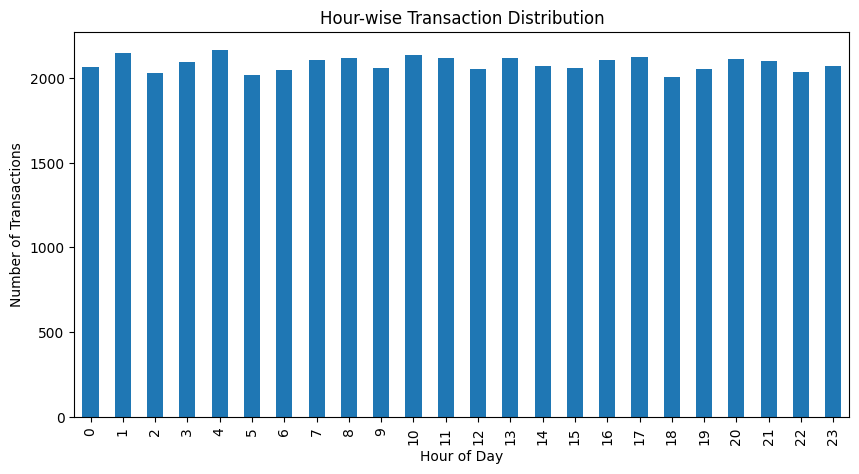

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
df["hour"].value_counts().sort_index().plot(kind="bar")

plt.title("Hour-wise Transaction Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.show()


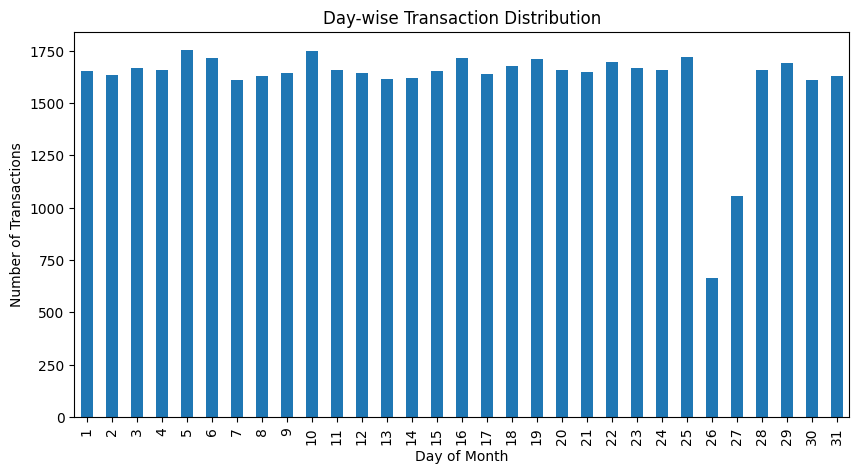

In [ ]:
df['day'].value_counts().sort_index().plot(kind='bar', figsize=(10,5))

plt.title('Day-wise Transaction Distribution')
plt.xlabel('Day of Month')
plt.ylabel('Number of Transactions')
plt.show()

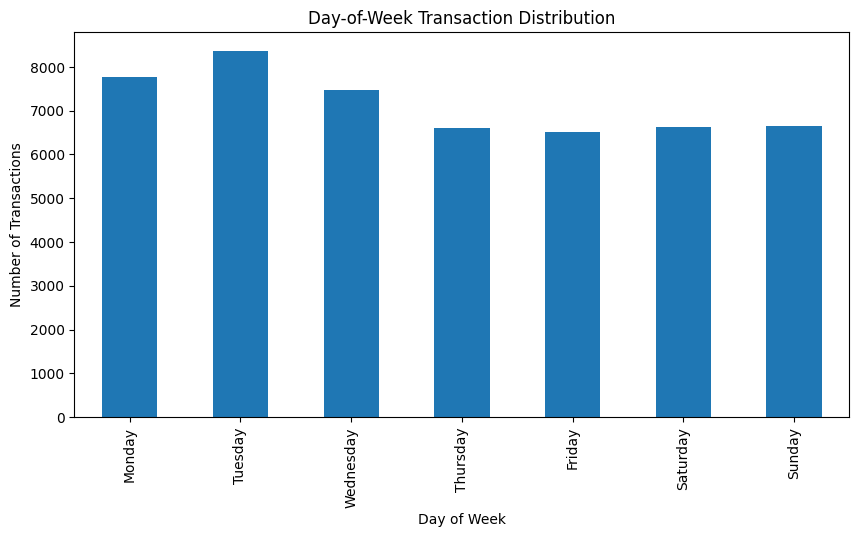

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']

df['day_of_week'].value_counts().reindex(day_order).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Day-of-Week Transaction Distribution')
plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')
plt.show()

In [ ]:
df["victim_city"].value_counts().head(10)

,count
victim_city,
Delhi NCR,11144
Mumbai,8990
Bengaluru,7879
Hyderabad,5963
Mewat Nuh,5116
Jamtara,4039
Jammu,4002
Kolkata,2867


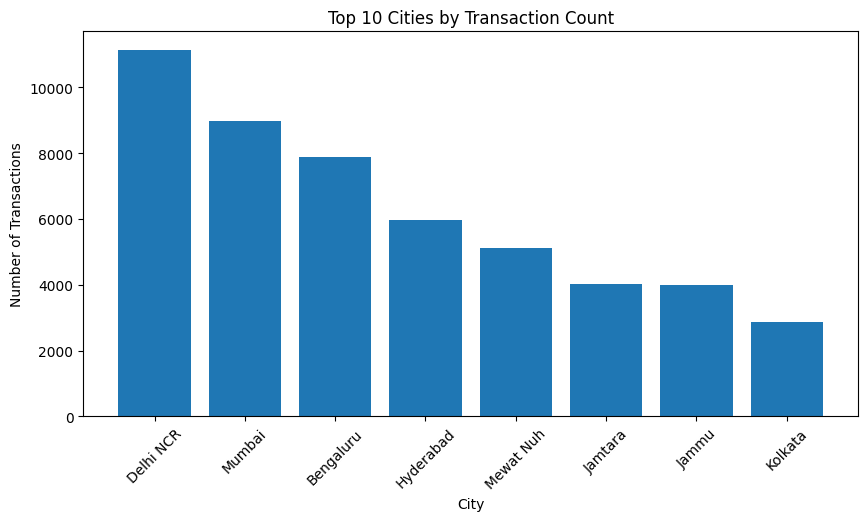

In [ ]:
import matplotlib.pyplot as plt

top_cities = df["victim_city"].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_cities.index, top_cities.values)

plt.title("Top 10 Cities by Transaction Count")
plt.xlabel("City")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

In [ ]:
!pip install seaborn

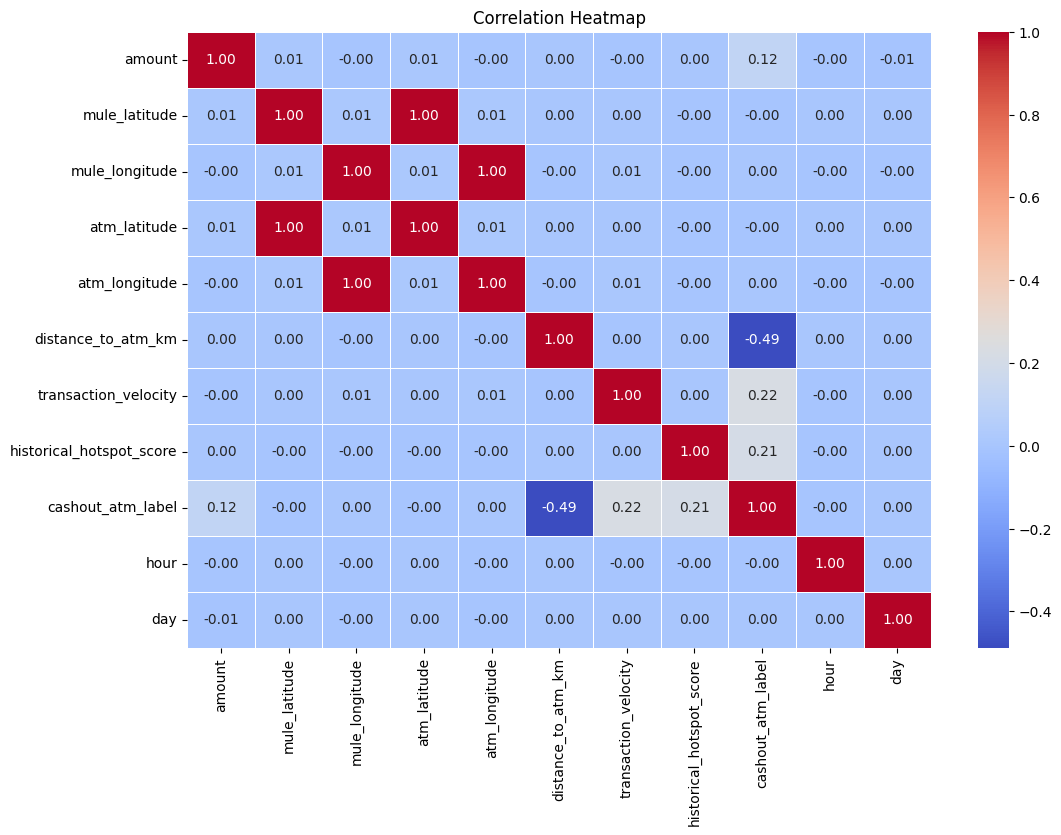

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numeric columns select karo
numeric_cols = df.select_dtypes(include='number')

# Correlation matrix
corr_matrix = numeric_cols.corr()

# Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

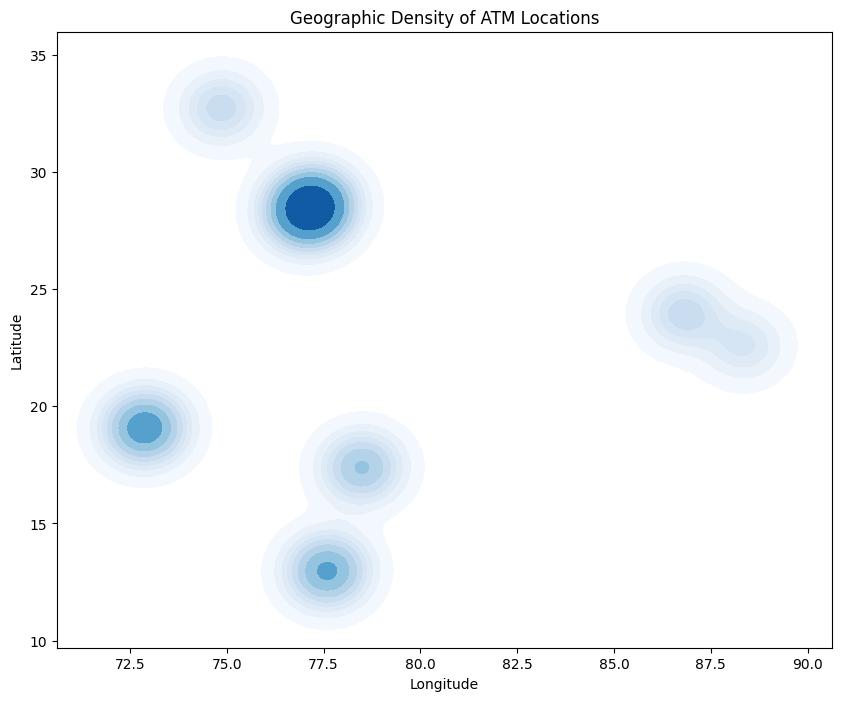

In [ ]:
plt.figure(figsize=(10, 8))

sns.kdeplot(
    data=df,
    x="atm_longitude",
    y="atm_latitude",
    fill=True,
    cmap="Blues",
    thresh=0.05
)

plt.title("Geographic Density of ATM Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

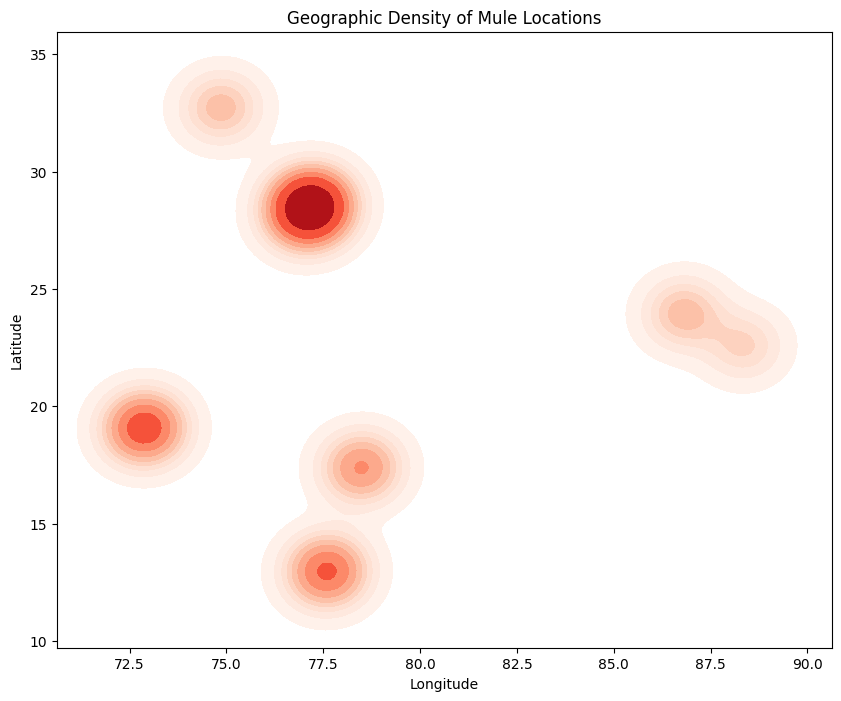

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.kdeplot(
    data=df,
    x="mule_longitude",
    y="mule_latitude",
    fill=True,
    cmap="Reds",
    thresh=0.05
)

plt.title("Geographic Density of Mule Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

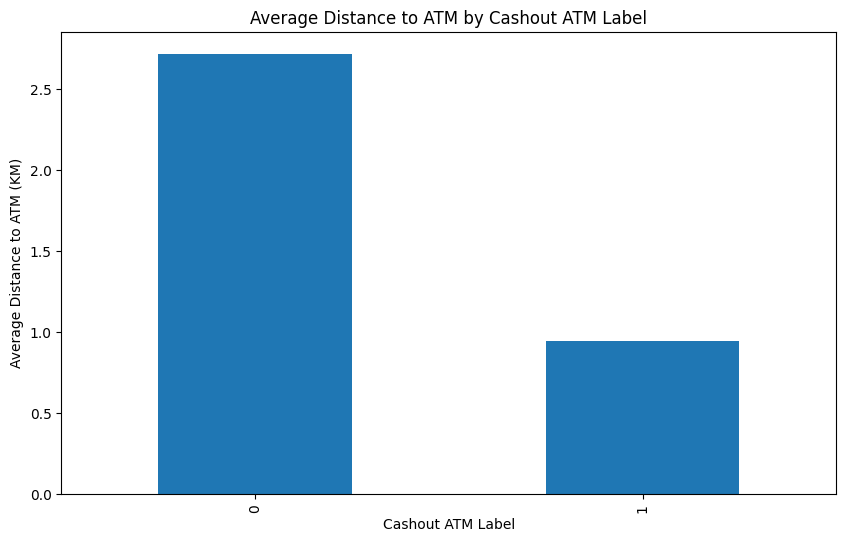

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

df.groupby("cashout_atm_label")["distance_to_atm_km"].mean().plot(
    kind="bar"
)

plt.title("Average Distance to ATM by Cashout ATM Label")
plt.xlabel("Cashout ATM Label")
plt.ylabel("Average Distance to ATM (KM)")

plt.show()

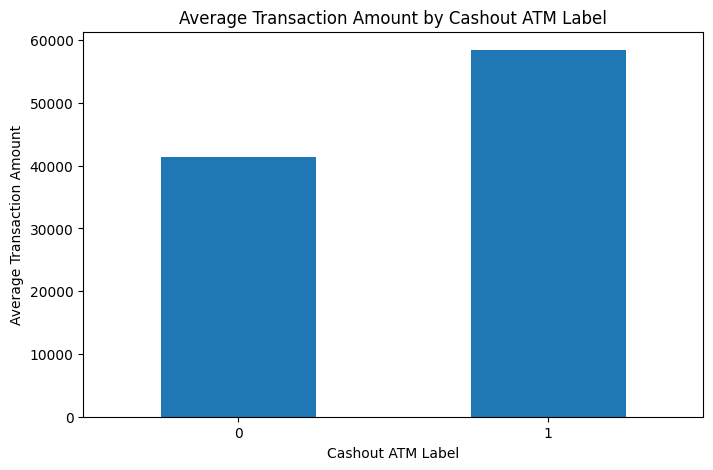

In [ ]:
import matplotlib.pyplot as plt

avg_amount = df.groupby("cashout_atm_label")["amount"].mean()

plt.figure(figsize=(8, 5))
avg_amount.plot(kind="bar")

plt.title("Average Transaction Amount by Cashout ATM Label")
plt.xlabel("Cashout ATM Label")
plt.ylabel("Average Transaction Amount")

plt.xticks(rotation=0)
plt.show()

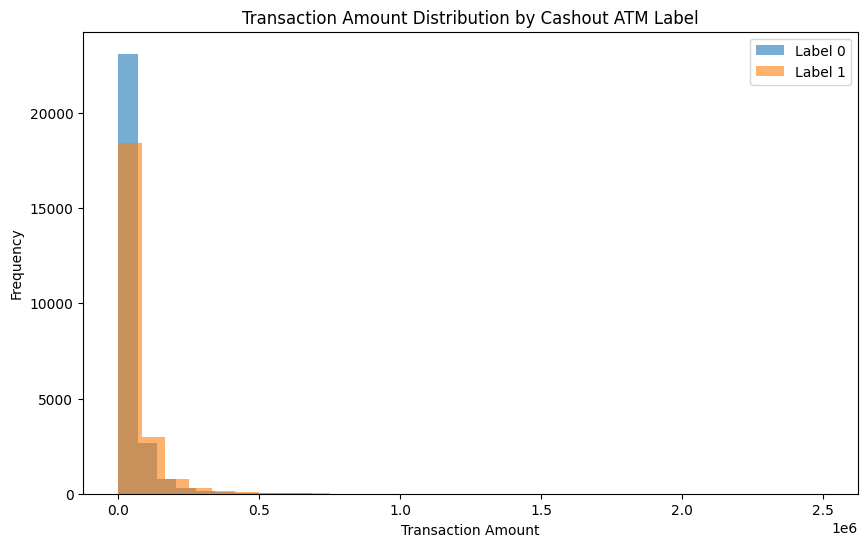

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for label in sorted(df["cashout_atm_label"].dropna().unique()):
    data = df[df["cashout_atm_label"] == label]["amount"]
    plt.hist(data, bins=30, alpha=0.6, label=f"Label {label}")

plt.title("Transaction Amount Distribution by Cashout ATM Label")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [ ]:
Q1 = df["amount"].quantile(0.25)
Q3 = df["amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["amount"] < lower_bound) |
    (df["amount"] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outlier Transactions:", len(outliers))

outliers[[
    "timestamp",
    "amount",
    "distance_to_atm_km",
    "transaction_velocity",
    "cashout_atm_label"
]].head(10)

Lower Bound: -53102.9375
Upper Bound: 122512.5625
Number of Outlier Transactions: 4192


,timestamp,amount,distance_to_atm_km,transaction_velocity,cashout_atm_label
3,2026-08-20 09:08:20,143678.41,1.535,6.96,1
6,2026-08-11 12:38:03,152838.04,0.167,7.95,1
20,2026-08-24 14:23:34,134889.83,2.329,2.15,1
31,2026-08-23 15:12:42,206386.52,0.908,1.29,1
71,2026-07-27 11:18:43,146069.85,3.210,7.01,0
73,2026-08-07 08:44:57,150408.17,1.504,1.75,0
82,2026-07-29 12:06:27,136719.06,3.060,1.59,0
106,2026-07-28 23:23:41,214229.79,3.471,5.32,0
113,2026-08-08 06:57:57,404160.08,6.446,0.86,0
122,2026-08-13 08:06:21,125878.66,1.252,3.13,1


In [ ]:
df_ml = df.copy()

# Convert timestamp to datetime
df_ml['timestamp'] = pd.to_datetime(df_ml['timestamp'])

# Extract time-based features
df_ml['hour'] = df_ml['timestamp'].dt.hour
df_ml['day'] = df_ml['timestamp'].dt.day
df_ml['month'] = df_ml['timestamp'].dt.month
df_ml['day_of_week'] = df_ml['timestamp'].dt.dayofweek

# Drop original timestamp
df_ml = df_ml.drop(columns=['timestamp'])

print(df_ml.head())
print(df_ml.shape)

      amount victim_city  mule_latitude  mule_longitude  atm_latitude  \
0   46461.79   Delhi NCR      28.610367       77.272456     28.597591   
1   23107.42      Mumbai      19.136144       72.846963     19.114287   
2   54855.48     Jamtara      23.898299       86.787236     23.904401   
3  143678.41     Kolkata      22.580397       88.418383     22.577984   
4   20794.24   Delhi NCR      28.575797       77.275633     28.572203   

   atm_longitude  distance_to_atm_km  transaction_velocity  \
0      77.271766               1.420                  1.50   
1      72.861431               2.862                  5.04   
2      86.760240               2.822                  2.87   
3      88.403632               1.535                  6.96   
4      77.280555               0.624                  0.42   

   historical_hotspot_score  cashout_atm_label  hour  day  day_of_week  month  
0                    0.3934                  1    14   22            5      8  
1                    0.6350 

cashout_atm_label
0    27215
1    22785
Name: count, dtype: int64


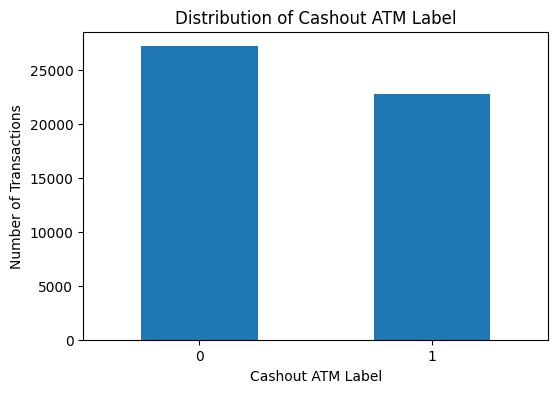

In [ ]:
print(df_ml['cashout_atm_label'].value_counts())

plt.figure(figsize=(6,4))
df_ml['cashout_atm_label'].value_counts().plot(kind='bar')
plt.title('Distribution of Cashout ATM Label')
plt.xlabel('Cashout ATM Label')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.show()

In [ ]:
X = df_ml.drop('cashout_atm_label', axis=1)
y = df_ml['cashout_atm_label']

# One-hot encode the city column
X = pd.get_dummies(X, columns=['victim_city'], drop_first=True)

# Check the shape
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature shape: (50000, 19)
Target shape: (50000,)


,amount,mule_latitude,mule_longitude,atm_latitude,atm_longitude,distance_to_atm_km,transaction_velocity,historical_hotspot_score,hour,day,day_of_week,month,victim_city_Delhi NCR,victim_city_Hyderabad,victim_city_Jammu,victim_city_Jamtara,victim_city_Kolkata,victim_city_Mewat Nuh,victim_city_Mumbai
0,46461.79,28.610367,77.272456,28.597591,77.271766,1.420,1.50,0.3934,14,22,5,8,True,False,False,False,False,False,False
1,23107.42,19.136144,72.846963,19.114287,72.861431,2.862,5.04,0.6350,13,14,4,8,False,False,False,False,False,False,True
2,54855.48,23.898299,86.787236,23.904401,86.760240,2.822,2.87,0.1511,4,23,6,8,False,False,False,True,False,False,False
3,143678.41,22.580397,88.418383,22.577984,88.403632,1.535,6.96,0.7814,9,20,3,8,False,False,False,False,True,False,False
4,20794.24,28.575797,77.275633,28.572203,77.280555,0.624,0.42,0.1580,15,11,1,8,True,False,False,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40000, 19)
X_test shape: (10000, 19)
y_train shape: (40000,)
y_test shape: (10000,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns
numeric_cols = [
    'amount',
    'mule_latitude',
    'mule_longitude',
    'atm_latitude',
    'atm_longitude',
    'distance_to_atm_km',
    'transaction_velocity',
    'historical_hotspot_score',
    'hour',
    'day',
    'day_of_week',
    'month'
]

# Scale numerical features
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Data scaling completed successfully!")

Data scaling completed successfully!


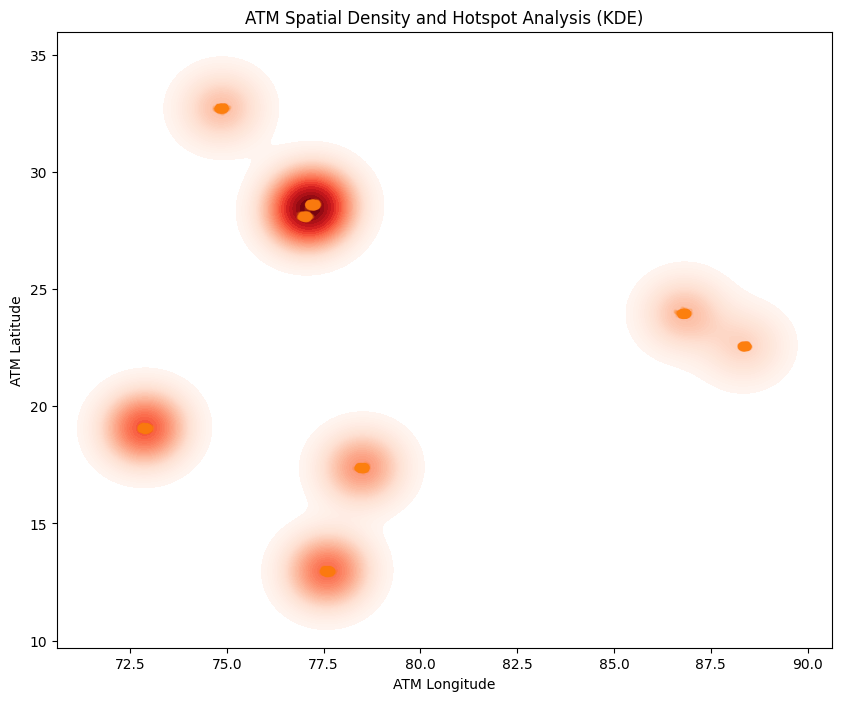

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.kdeplot(
    data=df,
    x="atm_longitude",
    y="atm_latitude",
    fill=True,
    cmap="Reds",
    levels=50,
    thresh=0.05
)

plt.scatter(
    df["atm_longitude"],
    df["atm_latitude"],
    s=5,
    alpha=0.15
)

plt.title("ATM Spatial Density and Hotspot Analysis (KDE)")
plt.xlabel("ATM Longitude")
plt.ylabel("ATM Latitude")

plt.show()

In [ ]:
from sklearn.neighbors import KernelDensity
import numpy as np

# Remove rows with missing ATM coordinates
coords = df[['atm_latitude', 'atm_longitude']].dropna()

# Use a sample for faster KDE fitting
sample_size = min(10000, len(coords))
coords_sample = coords.sample(n=sample_size, random_state=42)

# Fit KDE
kde = KernelDensity(
    bandwidth=0.5,
    kernel='gaussian'
)

kde.fit(coords_sample)

# Calculate hotspot scores in batches
scores = []
batch_size = 5000

for start in range(0, len(coords), batch_size):
    batch = coords.iloc[start:start + batch_size]
    batch_scores = np.exp(kde.score_samples(batch))
    scores.extend(batch_scores)

# Put scores back into the dataframe
df.loc[coords.index, 'spatial_hotspot_score'] = scores

print(df[['atm_latitude', 'atm_longitude', 'spatial_hotspot_score']].head())

print("\nSpatial Hotspot Score Summary:")
print(df['spatial_hotspot_score'].describe())

   atm_latitude  atm_longitude  spatial_hotspot_score
0     28.597591      77.271766               0.173135
1     19.114287      72.861431               0.111694
2     23.904401      86.760240               0.052584
3     22.577984      88.403632               0.035523
4     28.572203      77.280555               0.173823

Spatial Hotspot Score Summary:
count    50000.000000
mean         0.108125
std          0.045129
min          0.033720
25%          0.078368
50%          0.109008
75%          0.146151
max          0.180634
Name: spatial_hotspot_score, dtype: float64


In [ ]:
from sklearn.neighbors import KernelDensity
import numpy as np

# ATM coordinates
coords = df[['atm_latitude', 'atm_longitude']].dropna()

# Use a sample for faster computation
sample_size = min(10000, len(coords))
coords_sample = coords.sample(n=sample_size, random_state=42)

# Create and fit KDE model
kde = KernelDensity(
    bandwidth=0.5,
    kernel='gaussian'
)

kde.fit(coords_sample)

# Calculate KDE score in batches
scores = []
batch_size = 5000

for start in range(0, len(coords), batch_size):
    batch = coords.iloc[start:start + batch_size]
    batch_scores = np.exp(kde.score_samples(batch))
    scores.extend(batch_scores)

# Add score back to original dataframe
df.loc[coords.index, 'spatial_hotspot_score'] = scores

# Check results
print(df[['atm_latitude', 'atm_longitude', 'spatial_hotspot_score']].head())

print("\nSpatial Hotspot Score Summary:")
print(df['spatial_hotspot_score'].describe())

   atm_latitude  atm_longitude  spatial_hotspot_score
0     28.597591      77.271766               0.173135
1     19.114287      72.861431               0.111694
2     23.904401      86.760240               0.052584
3     22.577984      88.403632               0.035523
4     28.572203      77.280555               0.173823

Spatial Hotspot Score Summary:
count    50000.000000
mean         0.108125
std          0.045129
min          0.033720
25%          0.078368
50%          0.109008
75%          0.146151
max          0.180634
Name: spatial_hotspot_score, dtype: float64


In [ ]:
print("Current dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Current dataset shape: (50000, 15)

Columns:
['timestamp', 'amount', 'victim_city', 'mule_latitude', 'mule_longitude', 'atm_latitude', 'atm_longitude', 'distance_to_atm_km', 'transaction_velocity', 'historical_hotspot_score', 'cashout_atm_label', 'hour', 'day', 'day_of_week', 'spatial_hotspot_score']

Data types:
timestamp                   datetime64[ns]
amount                             float64
victim_city                         object
mule_latitude                      float64
mule_longitude                     float64
atm_latitude                       float64
atm_longitude                      float64
distance_to_atm_km                 float64
transaction_velocity               float64
historical_hotspot_score           float64
cashout_atm_label                    int64
hour                                 int32
day                                  int32
day_of_week                         object
spatial_hotspot_score              float64
dtype: object

Missing values:
Series([]

In [ ]:
print(df.columns.tolist())

['timestamp', 'amount', 'victim_city', 'mule_latitude', 'mule_longitude', 'atm_latitude', 'atm_longitude', 'distance_to_atm_km', 'transaction_velocity', 'historical_hotspot_score', 'cashout_atm_label', 'hour', 'day', 'day_of_week', 'spatial_hotspot_score']


In [ ]:
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

# Check the new features
print(df[['timestamp', 'hour', 'day', 'day_of_week', 'month']].head())

# Check updated shape
print("\nUpdated dataset shape:", df.shape)

            timestamp  hour  day  day_of_week  month
0 2026-08-22 14:13:55    14   22            5      8
1 2026-08-14 13:22:56    13   14            4      8
2 2026-08-23 04:25:04     4   23            6      8
3 2026-08-20 09:08:20     9   20            3      8
4 2026-08-11 15:31:38    15   11            1      8

Updated dataset shape: (50000, 16)


In [ ]:
df = pd.get_dummies(df, columns=['victim_city'], drop_first=True)

# Check the updated dataframe
print("Updated dataset shape:", df.shape)

# Show the city-related columns
print("\nEncoded city columns:")
print([col for col in df.columns if col.startswith('victim_city_')])

Updated dataset shape: (50000, 22)

Encoded city columns:
['victim_city_Delhi NCR', 'victim_city_Hyderabad', 'victim_city_Jammu', 'victim_city_Jamtara', 'victim_city_Kolkata', 'victim_city_Mewat Nuh', 'victim_city_Mumbai']


In [ ]:
y = df['cashout_atm_label']

# Define input features
X = df.drop(columns=['cashout_atm_label', 'timestamp'])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

X shape: (50000, 20)
y shape: (50000,)

Feature columns:
['amount', 'mule_latitude', 'mule_longitude', 'atm_latitude', 'atm_longitude', 'distance_to_atm_km', 'transaction_velocity', 'historical_hotspot_score', 'hour', 'day', 'day_of_week', 'spatial_hotspot_score', 'month', 'victim_city_Delhi NCR', 'victim_city_Hyderabad', 'victim_city_Jammu', 'victim_city_Jamtara', 'victim_city_Kolkata', 'victim_city_Mewat Nuh', 'victim_city_Mumbai']

Target distribution:
cashout_atm_label
0    27215
1    22785
Name: count, dtype: int64

Target percentage:
cashout_atm_label
0    54.43
1    45.57
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

# First split: 70% training and 30% temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: divide temporary data into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

print("\nClass distribution:")
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_val.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Training set: (35000, 20) (35000,)
Validation set: (7500, 20) (7500,)
Test set: (7500, 20) (7500,)

Class distribution:
Train:
cashout_atm_label
0    0.544286
1    0.455714
Name: proportion, dtype: float64

Validation:
cashout_atm_label
0    0.544267
1    0.455733
Name: proportion, dtype: float64

Test:
cashout_atm_label
0    0.5444
1    0.4556
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)

Scaling completed!
(35000, 20)
(7500, 20)
(7500, 20)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(64, activation='relu', input_shape=(20,)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8028 - loss: 0.4281 - val_accuracy: 0.8717 - val_loss: 0.2898
Epoch 2/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8718 - loss: 0.2927 - val_accuracy: 0.9191 - val_loss: 0.2050
Epoch 3/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9032 - loss: 0.2240 - val_accuracy: 0.9387 - val_loss: 0.1512
Epoch 4/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9207 - loss: 0.1873 - val_accuracy: 0.9501 - val_loss: 0.1287
Epoch 5/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9322 - loss: 0.1642 - val_accuracy: 0.9623 - val_loss: 0.1062
Epoch 6/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9406 - loss: 0.1465 - val_accuracy: 0.9635 - val_loss: 0.0934
Epoch 7/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9468 - loss: 0.1317 - val_accuracy: 0.9616 - val_loss: 0.0936
Epoch 8/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9498 - loss: 0.1233 - 

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - accuracy: 0.9872 - loss: 0.0360
Test Loss: 0.035962242633104324
Test Accuracy: 0.9872000217437744


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions
y_pred_prob = model.predict(X_test_scaled)

# Convert probabilities to 0 or 1
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
print(confusion_matrix(y_test, y_pred))

235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4083
           1       0.99      0.98      0.99      3417

    accuracy                           0.99      7500
   macro avg       0.99      0.99      0.99      7500
weighted avg       0.99      0.99      0.99      7500

[[4048   35]
 [  61 3356]]


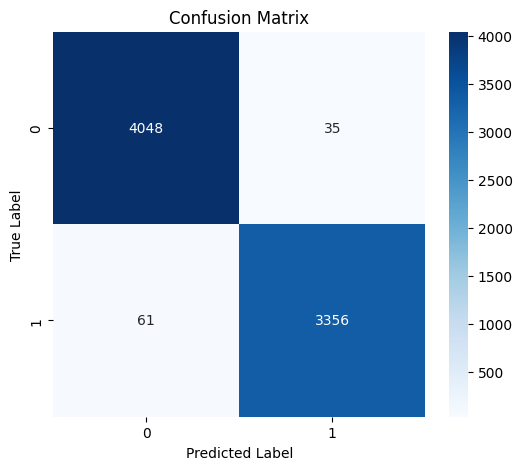

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
model.save("cashout_atm_model.keras")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
print("spatial_hotspot_score exists:", 'spatial_hotspot_score' in df.columns)

print("\nCurrent shape:", df.shape)

if 'spatial_hotspot_score' in df.columns:
    print("\nSpatial Hotspot Score Summary:")
    print(df['spatial_hotspot_score'].describe())

spatial_hotspot_score exists: True

Current shape: (50000, 22)

Spatial Hotspot Score Summary:
count    50000.000000
mean         0.108125
std          0.045129
min          0.033720
25%          0.078368
50%          0.109008
75%          0.146151
max          0.180634
Name: spatial_hotspot_score, dtype: float64


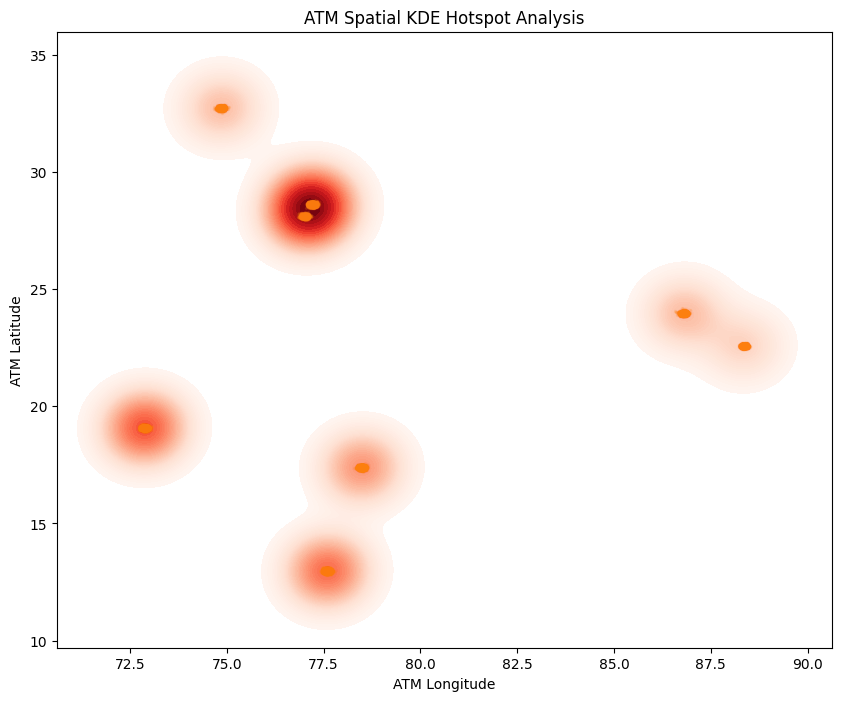

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.kdeplot(
    data=df,
    x='atm_longitude',
    y='atm_latitude',
    fill=True,
    cmap='Reds',
    thresh=0.05,
    levels=50
)

plt.scatter(
    df['atm_longitude'],
    df['atm_latitude'],
    s=2,
    alpha=0.15
)

plt.title('ATM Spatial KDE Hotspot Analysis')
plt.xlabel('ATM Longitude')
plt.ylabel('ATM Latitude')
plt.show()

In [ ]:
print(df.columns.tolist())

['timestamp', 'amount', 'mule_latitude', 'mule_longitude', 'atm_latitude', 'atm_longitude', 'distance_to_atm_km', 'transaction_velocity', 'historical_hotspot_score', 'cashout_atm_label', 'hour', 'day', 'day_of_week', 'spatial_hotspot_score', 'month', 'victim_city_Delhi NCR', 'victim_city_Hyderabad', 'victim_city_Jammu', 'victim_city_Jamtara', 'victim_city_Kolkata', 'victim_city_Mewat Nuh', 'victim_city_Mumbai']


In [ ]:
from sklearn.model_selection import train_test_split

# Target column
y = df['cashout_atm_label']

# Features: remove the target column
X = df.drop(columns=['cashout_atm_label'])

# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: 15% validation, 15% testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Check the split sizes
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

# Check class distribution
print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation class distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Training set: (35000, 21) (35000,)
Validation set: (7500, 21) (7500,)
Test set: (7500, 21) (7500,)

Training class distribution:
cashout_atm_label
0    0.544286
1    0.455714
Name: proportion, dtype: float64

Validation class distribution:
cashout_atm_label
0    0.544267
1    0.455733
Name: proportion, dtype: float64

Test class distribution:
cashout_atm_label
0    0.5444
1    0.4556
Name: proportion, dtype: float64


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Remove timestamp because Logistic Regression cannot directly use datetime/text values
X_train_lr = X_train.drop(columns=['timestamp'], errors='ignore')
X_val_lr = X_val.drop(columns=['timestamp'], errors='ignore')
X_test_lr = X_test.drop(columns=['timestamp'], errors='ignore')

# Build Logistic Regression pipeline
logistic_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train the model
logistic_model.fit(X_train_lr, y_train)

# Validation predictions
y_val_pred_lr = logistic_model.predict(X_val_lr)
y_val_prob_lr = logistic_model.predict_proba(X_val_lr)[:, 1]

# Validation metrics
print("LOGISTIC REGRESSION - VALIDATION RESULTS")
print("-" * 45)

print("Accuracy :", accuracy_score(y_val, y_val_pred_lr))
print("Precision:", precision_score(y_val, y_val_pred_lr))
print("Recall   :", recall_score(y_val, y_val_pred_lr))
print("F1 Score :", f1_score(y_val, y_val_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_val, y_val_prob_lr))

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_lr))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_lr))

LOGISTIC REGRESSION - VALIDATION RESULTS
---------------------------------------------
Accuracy : 0.8156
Precision: 0.781777900858488
Recall   : 0.8259215915740199
F1 Score : 0.8032437046521553
ROC-AUC  : 0.9006008052019613

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.81      0.83      4082
           1       0.78      0.83      0.80      3418

    accuracy                           0.82      7500
   macro avg       0.81      0.82      0.81      7500
weighted avg       0.82      0.82      0.82      7500


Confusion Matrix:

[[3294  788]
 [ 595 2823]]


In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Remove timestamp
X_train_rf = X_train.drop(columns=['timestamp'], errors='ignore')
X_val_rf = X_val.drop(columns=['timestamp'], errors='ignore')
X_test_rf = X_test.drop(columns=['timestamp'], errors='ignore')

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_rf, y_train)

# Validation predictions
y_val_pred_rf = rf_model.predict(X_val_rf)
y_val_prob_rf = rf_model.predict_proba(X_val_rf)[:, 1]

# Validation results
print("RANDOM FOREST - VALIDATION RESULTS")
print("-" * 45)

print("Accuracy :", accuracy_score(y_val, y_val_pred_rf))
print("Precision:", precision_score(y_val, y_val_pred_rf))
print("Recall   :", recall_score(y_val, y_val_pred_rf))
print("F1 Score :", f1_score(y_val, y_val_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_val, y_val_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_rf))

RANDOM FOREST - VALIDATION RESULTS
---------------------------------------------
Accuracy : 0.9997333333333334
Precision: 0.9997074312463429
Recall   : 0.9997074312463429
F1 Score : 0.9997074312463429
ROC-AUC  : 0.9999998566542119

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4082
           1       1.00      1.00      1.00      3418

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
weighted avg       1.00      1.00      1.00      7500


Confusion Matrix:

[[4081    1]
 [   1 3417]]


In [ ]:
print("Available model variables:")

for name in list(globals().keys()):
    if any(word in name.lower() for word in ['forest', 'rf', 'model']):
        print(name)

Available model variables:
model
logistic_model
RandomForestClassifier
X_train_rf
X_val_rf
X_test_rf
rf_model
y_val_pred_rf
y_val_prob_rf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train_rf.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("RANDOM FOREST FEATURE IMPORTANCE")
print(feature_importance)

RANDOM FOREST FEATURE IMPORTANCE
                     Feature  Importance
5         distance_to_atm_km    0.520728
6       transaction_velocity    0.177491
0                     amount    0.133800
7   historical_hotspot_score    0.132435
3               atm_latitude    0.005426
11     spatial_hotspot_score    0.005408
4              atm_longitude    0.005314
2             mule_longitude    0.005285
1              mule_latitude    0.005197
8                       hour    0.003130
9                        day    0.003053
10               day_of_week    0.001762
12                     month    0.000329
18     victim_city_Mewat Nuh    0.000124
14     victim_city_Hyderabad    0.000111
16       victim_city_Jamtara    0.000099
19        victim_city_Mumbai    0.000098
13     victim_city_Delhi NCR    0.000090
15         victim_city_Jammu    0.000062
17       victim_city_Kolkata    0.000060


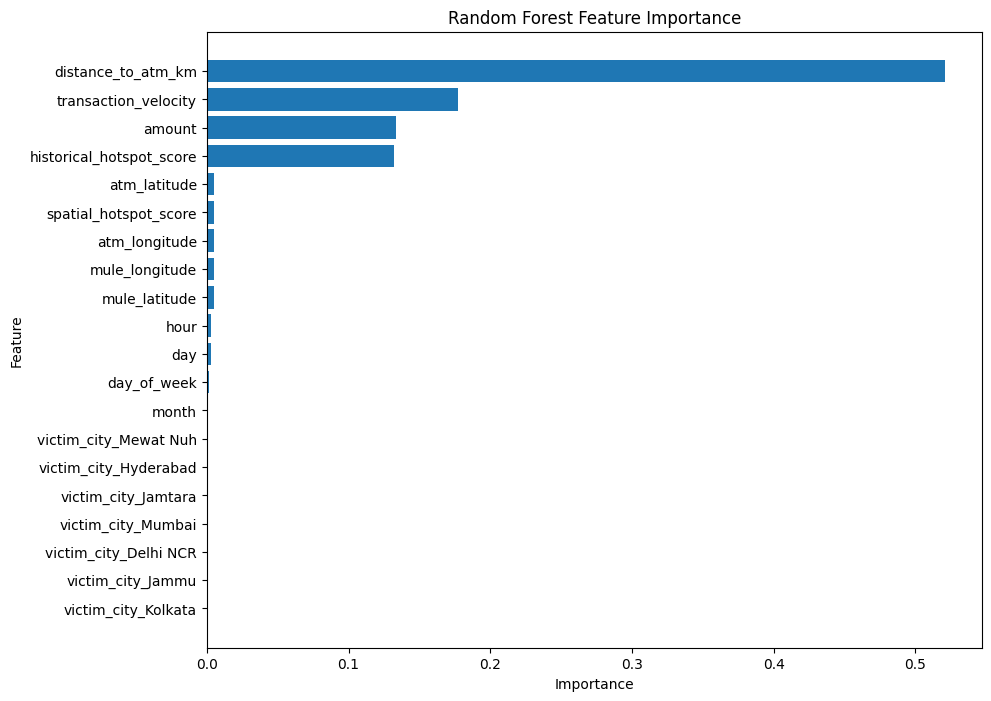

In [ ]:
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [ ]:
print("TARGET DISTRIBUTION")
print(df['cashout_atm_label'].value_counts(normalize=True))

print("\nFEATURE MEANS BY TARGET CLASS")
leakage_check = df.groupby('cashout_atm_label')[
    [
        'distance_to_atm_km',
        'transaction_velocity',
        'amount',
        'historical_hotspot_score',
        'spatial_hotspot_score'
    ]
].mean()

print(leakage_check)

TARGET DISTRIBUTION
cashout_atm_label
0    0.5443
1    0.4557
Name: proportion, dtype: float64

FEATURE MEANS BY TARGET CLASS
                   distance_to_atm_km  transaction_velocity        amount  \
cashout_atm_label                                                           
0                            2.717954              2.186822  41310.555412   
1                            0.943226              3.289070  58423.606504   

                   historical_hotspot_score  spatial_hotspot_score  
cashout_atm_label                                                   
0                                  0.361798               0.108199  
1                                  0.446150               0.108035  


In [ ]:
print("FEATURE CORRELATION WITH TARGET")

correlations = df[
    [
        'distance_to_atm_km',
        'transaction_velocity',
        'amount',
        'historical_hotspot_score',
        'spatial_hotspot_score',
        'cashout_atm_label'
    ]
].corr()['cashout_atm_label'].sort_values(ascending=False)

print(correlations)

FEATURE CORRELATION WITH TARGET
cashout_atm_label           1.000000
transaction_velocity        0.221442
historical_hotspot_score    0.209217
amount                      0.115637
spatial_hotspot_score      -0.001808
distance_to_atm_km         -0.488137
Name: cashout_atm_label, dtype: float64


In [ ]:
print("TARGET DISTRIBUTION:")

target_col = 'cashout_atm_label'

print(df[target_col].value_counts())
print("\nPercentage distribution:")
print(df[target_col].value_counts(normalize=True) * 100)

TARGET DISTRIBUTION:
cashout_atm_label
0    27215
1    22785
Name: count, dtype: int64

Percentage distribution:
cashout_atm_label
0    54.43
1    45.57
Name: proportion, dtype: float64


In [ ]:
print("TARGET DISTRIBUTION:")
print(df['cashout_atm_label'].value_counts())

print("\nTARGET PERCENTAGE:")
print(df['cashout_atm_label'].value_counts(normalize=True) * 100)

TARGET DISTRIBUTION:
cashout_atm_label
0    27215
1    22785
Name: count, dtype: int64

TARGET PERCENTAGE:
cashout_atm_label
0    54.43
1    45.57
Name: proportion, dtype: float64


In [ ]:
print("FEATURE MEANS BY TARGET CLASS")
print(df.groupby('cashout_atm_label')[
    [
        'distance_to_atm_km',
        'transaction_velocity',
        'amount',
        'historical_hotspot_score',
        'spatial_hotspot_score'
    ]
].mean())

FEATURE MEANS BY TARGET CLASS
                   distance_to_atm_km  transaction_velocity        amount  \
cashout_atm_label                                                           
0                            2.717954              2.186822  41310.555412   
1                            0.943226              3.289070  58423.606504   

                   historical_hotspot_score  spatial_hotspot_score  
cashout_atm_label                                                   
0                                  0.361798               0.108199  
1                                  0.446150               0.108035  


In [ ]:
print("CORRELATION WITH TARGET:")
print(
    df[
        [
            'distance_to_atm_km',
            'transaction_velocity',
            'amount',
            'historical_hotspot_score',
            'spatial_hotspot_score',
            'cashout_atm_label'
        ]
    ].corr()['cashout_atm_label'].sort_values(ascending=False)
)

CORRELATION WITH TARGET:
cashout_atm_label           1.000000
transaction_velocity        0.221442
historical_hotspot_score    0.209217
amount                      0.115637
spatial_hotspot_score      -0.001808
distance_to_atm_km         -0.488137
Name: cashout_atm_label, dtype: float64


In [ ]:
print("\nDISTANCE STATISTICS BY TARGET:")
print(
    df.groupby('cashout_atm_label')['distance_to_atm_km'].describe()
)


DISTANCE STATISTICS BY TARGET:
                     count      mean       std  min    25%    50%     75%  \
cashout_atm_label                                                           
0                  27215.0  2.717954  1.938741  0.1  1.557  2.279  3.5395   
1                  22785.0  0.943226  0.995561  0.1  0.392  0.736  1.1630   

                      max  
cashout_atm_label          
0                  16.884  
1                  14.571  


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_val_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_val_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_val_pred_rf))

print("\nROC-AUC:", roc_auc_score(y_test, y_val_prob_rf))

Accuracy: 0.5057333333333334

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.55      0.55      4083
           1       0.46      0.46      0.46      3417

    accuracy                           0.51      7500
   macro avg       0.50      0.50      0.50      7500
weighted avg       0.51      0.51      0.51      7500


Confusion Matrix:
[[2229 1854]
 [1853 1564]]

ROC-AUC: 0.5027513668493194


In [ ]:
print("Features expected by model:")
print(list(rf_model.feature_names_in_))

print("\nFeatures currently in X_train:")
print(list(X_train.columns))

Features expected by model:
['amount', 'mule_latitude', 'mule_longitude', 'atm_latitude', 'atm_longitude', 'distance_to_atm_km', 'transaction_velocity', 'historical_hotspot_score', 'hour', 'day', 'day_of_week', 'spatial_hotspot_score', 'month', 'victim_city_Delhi NCR', 'victim_city_Hyderabad', 'victim_city_Jammu', 'victim_city_Jamtara', 'victim_city_Kolkata', 'victim_city_Mewat Nuh', 'victim_city_Mumbai']

Features currently in X_train:
['timestamp', 'amount', 'mule_latitude', 'mule_longitude', 'atm_latitude', 'atm_longitude', 'distance_to_atm_km', 'transaction_velocity', 'historical_hotspot_score', 'hour', 'day', 'day_of_week', 'spatial_hotspot_score', 'month', 'victim_city_Delhi NCR', 'victim_city_Hyderabad', 'victim_city_Jammu', 'victim_city_Jamtara', 'victim_city_Kolkata', 'victim_city_Mewat Nuh', 'victim_city_Mumbai']


In [ ]:
expected_features = list(rf_model.feature_names_in_)

X_train_fixed = X_train.reindex(columns=expected_features)
X_val_fixed = X_val.reindex(columns=expected_features)

print("Train accuracy:",
      accuracy_score(y_train, rf_model.predict(X_train_fixed)))

print("Validation accuracy:",
      accuracy_score(y_val, rf_model.predict(X_val_fixed)))

Train accuracy: 1.0
Validation accuracy: 0.9997333333333334


In [ ]:
X = df.drop(columns=['cashout_atm_label', 'timestamp'])
y = df['cashout_atm_label']

# Make sure columns match the model exactly
X = X[rf_model.feature_names_in_]

print("Feature count:", X.shape[1])
print(list(X.columns))

Feature count: 20
['amount', 'mule_latitude', 'mule_longitude', 'atm_latitude', 'atm_longitude', 'distance_to_atm_km', 'transaction_velocity', 'historical_hotspot_score', 'hour', 'day', 'day_of_week', 'spatial_hotspot_score', 'month', 'victim_city_Delhi NCR', 'victim_city_Hyderabad', 'victim_city_Jammu', 'victim_city_Jamtara', 'victim_city_Kolkata', 'victim_city_Mewat Nuh', 'victim_city_Mumbai']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

rf_model_new = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model_new.fit(X_train, y_train)

y_train_pred = rf_model_new.predict(X_train)
y_val_pred = rf_model_new.predict(X_val)
y_val_prob = rf_model_new.predict_proba(X_val)[:, 1]

print("TRAIN ACCURACY:", accuracy_score(y_train, y_train_pred))
print("VALIDATION ACCURACY:", accuracy_score(y_val, y_val_pred))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_val, y_val_pred))

print("\nCONFUSION MATRIX:")
print(confusion_matrix(y_val, y_val_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_val, y_val_prob))

TRAIN ACCURACY: 0.999835294117647
VALIDATION ACCURACY: 0.9992

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4082
           1       1.00      1.00      1.00      3418

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
weighted avg       1.00      1.00      1.00      7500


CONFUSION MATRIX:
[[4079    3]
 [   3 3415]]

ROC-AUC:
0.9999992832710591


In [ ]:
import pandas as pd

print(pd.crosstab(
    df['cashout_atm_label'],
    df['distance_to_atm_km'] < 1,
    normalize='index'
))

distance_to_atm_km     False     True 
cashout_atm_label                     
0                   0.833621  0.166379
1                   0.338688  0.661312


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

features = [
    'amount',
    'mule_latitude',
    'mule_longitude',
    'atm_latitude',
    'atm_longitude',
    'distance_to_atm_km',
    'transaction_velocity',
    'historical_hotspot_score',
    'spatial_hotspot_score',
    'hour',
    'day',
    'day_of_week',
    'month',
    'victim_city_Delhi NCR',
    'victim_city_Hyderabad',
    'victim_city_Jammu',
    'victim_city_Jamtara',
    'victim_city_Kolkata',
    'victim_city_Mewat Nuh',
    'victim_city_Mumbai'
]

results = []

for feature in features:
    X = df[[feature]]
    y = df['cashout_atm_label']

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)
    prob = model.predict_proba(X_val)[:, 1]

    results.append({
        'feature': feature,
        'accuracy': accuracy_score(y_val, pred),
        'roc_auc': roc_auc_score(y_val, prob)
    })

results_df = pd.DataFrame(results).sort_values(
    'roc_auc',
    ascending=False
)

print(results_df)

                     feature  accuracy   roc_auc
5         distance_to_atm_km    0.8290  0.841184
6       transaction_velocity    0.6449  0.651114
7   historical_hotspot_score    0.5766  0.584167
0                     amount    0.5338  0.548146
3               atm_latitude    0.5076  0.508504
4              atm_longitude    0.5115  0.508207
11               day_of_week    0.5443  0.505738
18     victim_city_Mewat Nuh    0.5443  0.504877
1              mule_latitude    0.5051  0.504328
19        victim_city_Mumbai    0.5443  0.503377
10                       day    0.5443  0.502425
9                       hour    0.5443  0.502239
14     victim_city_Hyderabad    0.5443  0.501558
8      spatial_hotspot_score    0.5032  0.501231
16       victim_city_Jamtara    0.5443  0.499687
17       victim_city_Kolkata    0.5443  0.498689
12                     month    0.5443  0.498524
13     victim_city_Delhi NCR    0.5443  0.497766
15         victim_city_Jammu    0.5443  0.493476
2             mule_l

In [ ]:
importance_df = pd.DataFrame({
    'feature': expected_features,
    'importance': rf_model.feature_importances_
}).sort_values(
    'importance',
    ascending=False
)

print(importance_df)

                     feature  importance
5         distance_to_atm_km    0.520728
6       transaction_velocity    0.177491
0                     amount    0.133800
7   historical_hotspot_score    0.132435
3               atm_latitude    0.005426
11     spatial_hotspot_score    0.005408
4              atm_longitude    0.005314
2             mule_longitude    0.005285
1              mule_latitude    0.005197
8                       hour    0.003130
9                        day    0.003053
10               day_of_week    0.001762
12                     month    0.000329
18     victim_city_Mewat Nuh    0.000124
14     victim_city_Hyderabad    0.000111
16       victim_city_Jamtara    0.000099
19        victim_city_Mumbai    0.000098
13     victim_city_Delhi NCR    0.000090
15         victim_city_Jammu    0.000062
17       victim_city_Kolkata    0.000060


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

target = 'cashout_atm_label'

features = [
    'amount',
    'mule_latitude',
    'mule_longitude',
    'atm_latitude',
    'atm_longitude',
    'distance_to_atm_km',
    'transaction_velocity',
    'historical_hotspot_score',
    'spatial_hotspot_score',
    'hour',
    'day',
    'day_of_week',
    'month',
    'victim_city_Delhi NCR',
    'victim_city_Hyderabad',
    'victim_city_Jammu',
    'victim_city_Jamtara',
    'victim_city_Kolkata',
    'victim_city_Mewat Nuh',
    'victim_city_Mumbai'
]

X = df[features].copy()
y = df[target].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_val)
y_prob = rf_model.predict_proba(X_val)[:, 1]

print("Train accuracy:", accuracy_score(y_train, rf_model.predict(X_train)))
print("Validation accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:")
print(classification_report(y_val, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\nROC-AUC:", roc_auc_score(y_val, y_prob))

Train accuracy: 1.0
Validation accuracy: 0.9993

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5443
           1       1.00      1.00      1.00      4557

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000


Confusion Matrix:
[[5441    2]
 [   5 4552]]

ROC-AUC: 0.9999989316132063


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Explicitly select features
feature_cols = [
    'amount',
    'mule_latitude',
    'mule_longitude',
    'atm_latitude',
    'atm_longitude',
    'distance_to_atm_km',
    'transaction_velocity',
    'historical_hotspot_score',
    'spatial_hotspot_score',
    'hour',
    'day',
    'day_of_week',
    'month',
    'victim_city_Delhi NCR',
    'victim_city_Hyderabad',
    'victim_city_Jammu',
    'victim_city_Jamtara',
    'victim_city_Kolkata',
    'victim_city_Mewat Nuh',
    'victim_city_Mumbai'
]

X = df[feature_cols]
y = df['cashout_atm_label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_val)
y_prob = rf_model.predict_proba(X_val)[:, 1]

print("Train Accuracy:",
      accuracy_score(y_train, rf_model.predict(X_train)))

print("Validation Accuracy:",
      accuracy_score(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

print("\nROC-AUC:",
      roc_auc_score(y_val, y_prob))

Train Accuracy: 1.0
Validation Accuracy: 0.9994666666666666

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4082
           1       1.00      1.00      1.00      3418

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
weighted avg       1.00      1.00      1.00      7500


ROC-AUC: 0.9999996416355297


In [ ]:
# ============================================================
# DURGAM ATM HOTSPOT PREDICTION - COMPLETE MODEL CODE
# ============================================================

# ---------------------------
# 1. IMPORT LIBRARIES
# ---------------------------

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# ---------------------------
# 2. CHECK DATA
# ---------------------------

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

# ---------------------------
# 3. CHECK TARGET DISTRIBUTION
# ---------------------------

print("\nTARGET DISTRIBUTION:")
print(df["cashout_atm_label"].value_counts())

print("\nTARGET PERCENTAGE:")
print(
    df["cashout_atm_label"]
    .value_counts(normalize=True)
    .mul(100)
)

# ---------------------------
# 4. DEFINE TARGET
# ---------------------------

target = "cashout_atm_label"

# IMPORTANT:
# Do NOT include the target column.
# Do NOT include timestamp unless you explicitly convert
# it into useful numeric/date features.

expected_features = [
    "amount",
    "mule_latitude",
    "mule_longitude",
    "atm_latitude",
    "atm_longitude",
    "distance_to_atm_km",
    "transaction_velocity",
    "historical_hotspot_score",
    "spatial_hotspot_score",
    "hour",
    "day",
    "day_of_week",
    "month",
    "victim_city_Delhi NCR",
    "victim_city_Hyderabad",
    "victim_city_Jammu",
    "victim_city_Jamtara",
    "victim_city_Kolkata",
    "victim_city_Mewat Nuh",
    "victim_city_Mumbai"
]

# ---------------------------
# 5. VERIFY FEATURES EXIST
# ---------------------------

missing_features = [
    col for col in expected_features
    if col not in df.columns
]

if missing_features:
    print("\nERROR - Missing features:")
    print(missing_features)
else:
    print("\nAll expected features are present.")

# ---------------------------
# 6. CREATE X AND y
# ---------------------------

X = df[expected_features].copy()
y = df[target].copy()

# Remove rows containing missing values
combined = pd.concat([X, y], axis=1).dropna()

X = combined[expected_features]
y = combined[target]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures used:")
print(X.columns.tolist())

# ---------------------------
# 7. TRAIN / VALIDATION SPLIT
# ---------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Validation shape:", X_val.shape)

# ---------------------------
# 8. TRAIN RANDOM FOREST
# ---------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# ---------------------------
# 9. MAKE PREDICTIONS
# ---------------------------

y_train_pred = rf_model.predict(X_train)
y_val_pred = rf_model.predict(X_val)

y_val_prob = rf_model.predict_proba(X_val)[:, 1]

# ---------------------------
# 10. EVALUATE MODEL
# ---------------------------

print("\n" + "=" * 60)
print("MODEL EVALUATION - ALL FEATURES")
print("=" * 60)

print(
    "\nTrain Accuracy:",
    accuracy_score(y_train, y_train_pred)
)

print(
    "Validation Accuracy:",
    accuracy_score(y_val, y_val_pred)
)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val,
        y_val_pred
    )
)

print(
    "\nROC-AUC:",
    roc_auc_score(
        y_val,
        y_val_prob
    )
)

# ---------------------------
# 11. FEATURE IMPORTANCE
# ---------------------------

importance_df = pd.DataFrame({
    "feature": expected_features,
    "importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

print(importance_df)

# ============================================================
# 12. EXPERIMENT:
# REMOVE distance_to_atm_km
# ============================================================

print("\n" + "=" * 60)
print("EXPERIMENT - WITHOUT distance_to_atm_km")
print("=" * 60)

features_without_distance = [
    col for col in expected_features
    if col != "distance_to_atm_km"
]

X_no_distance = df[
    features_without_distance
].copy()

combined_no_distance = pd.concat(
    [
        X_no_distance,
        y
    ],
    axis=1
).dropna()

X_no_distance = combined_no_distance[
    features_without_distance
]

y_no_distance = combined_no_distance[target]

# Split again
X_train_no_dist, X_val_no_dist, \
y_train_no_dist, y_val_no_dist = train_test_split(
    X_no_distance,
    y_no_distance,
    test_size=0.15,
    random_state=42,
    stratify=y_no_distance
)

# Train second model
rf_no_distance = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_no_distance.fit(
    X_train_no_dist,
    y_train_no_dist
)

# Predictions
y_train_pred_no_dist = rf_no_distance.predict(
    X_train_no_dist
)

y_val_pred_no_dist = rf_no_distance.predict(
    X_val_no_dist
)

y_val_prob_no_dist = rf_no_distance.predict_proba(
    X_val_no_dist
)[:, 1]

# Evaluation
print(
    "\nTrain Accuracy:",
    accuracy_score(
        y_train_no_dist,
        y_train_pred_no_dist
    )
)

print(
    "Validation Accuracy:",
    accuracy_score(
        y_val_no_dist,
        y_val_pred_no_dist
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_val_no_dist,
        y_val_pred_no_dist
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val_no_dist,
        y_val_pred_no_dist
    )
)

print(
    "\nROC-AUC:",
    roc_auc_score(
        y_val_no_dist,
        y_val_prob_no_dist
    )
)

# ============================================================
# 13. COMPARE BOTH MODELS
# ============================================================

all_features_accuracy = accuracy_score(
    y_val,
    y_val_pred
)

no_distance_accuracy = accuracy_score(
    y_val_no_dist,
    y_val_pred_no_dist
)

all_features_auc = roc_auc_score(
    y_val,
    y_val_prob
)

no_distance_auc = roc_auc_score(
    y_val_no_dist,
    y_val_prob_no_dist
)

comparison = pd.DataFrame({
    "Model": [
        "All Features",
        "Without distance_to_atm_km"
    ],
    "Validation Accuracy": [
        all_features_accuracy,
        no_distance_accuracy
    ],
    "ROC-AUC": [
        all_features_auc,
        no_distance_auc
    ]
})

print("\n" + "=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

print(comparison)

# ============================================================
# 14. TEST EACH TOP FEATURE INDIVIDUALLY
# ============================================================

print("\n" + "=" * 60)
print("SINGLE FEATURE EXPERIMENT")
print("=" * 60)

test_features = [
    "distance_to_atm_km",
    "transaction_velocity",
    "historical_hotspot_score",
    "spatial_hotspot_score",
    "amount"
]

results = []

for feature in test_features:

    X_single = df[[feature]].copy()

    temp_data = pd.concat(
        [
            X_single,
            df[[target]]
        ],
        axis=1
    ).dropna()

    X_single = temp_data[[feature]]
    y_single = temp_data[target]

    X_train_single, X_val_single, \
    y_train_single, y_val_single = train_test_split(
        X_single,
        y_single,
        test_size=0.15,
        random_state=42,
        stratify=y_single
    )

    model_single = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model_single.fit(
        X_train_single,
        y_train_single
    )

    y_pred_single = model_single.predict(
        X_val_single
    )

    y_prob_single = model_single.predict_proba(
        X_val_single
    )[:, 1]

    acc = accuracy_score(
        y_val_single,
        y_pred_single
    )

    auc = roc_auc_score(
        y_val_single,
        y_prob_single
    )

    results.append({
        "feature": feature,
        "accuracy": acc,
        "roc_auc": auc
    })

single_feature_results = pd.DataFrame(
    results
).sort_values(
    "roc_auc",
    ascending=False
)

print(single_feature_results)

# ============================================================
# 15. CHECK RELATIONSHIP BETWEEN TARGET AND DISTANCE
# ============================================================

print("\n" + "=" * 60)
print("DISTANCE STATISTICS BY TARGET")
print("=" * 60)

print(
    df.groupby("cashout_atm_label")[
        "distance_to_atm_km"
    ].describe()
)

print("\n" + "=" * 60)
print("DISTANCE CORRELATION WITH TARGET")
print("=" * 60)

print(
    df[
        [
            "cashout_atm_label",
            "distance_to_atm_km"
        ]
    ].corr()
)

# ============================================================
# 16. CHECK FOR POSSIBLE LEAKAGE
# ============================================================

print("\n" + "=" * 60)
print("POSSIBLE LEAKAGE CHECK")
print("=" * 60)

correlation_features = [
    "amount",
    "distance_to_atm_km",
    "transaction_velocity",
    "historical_hotspot_score",
    "spatial_hotspot_score"
]

correlation_data = df[
    correlation_features + [target]
].copy()

print(
    correlation_data.corr()[target]
    .sort_values(
        ascending=False
    )
)

print("\nDONE!")

Dataset shape: (50000, 22)

Columns:
['timestamp', 'amount', 'mule_latitude', 'mule_longitude', 'atm_latitude', 'atm_longitude', 'distance_to_atm_km', 'transaction_velocity', 'historical_hotspot_score', 'cashout_atm_label', 'hour', 'day', 'day_of_week', 'spatial_hotspot_score', 'month', 'victim_city_Delhi NCR', 'victim_city_Hyderabad', 'victim_city_Jammu', 'victim_city_Jamtara', 'victim_city_Kolkata', 'victim_city_Mewat Nuh', 'victim_city_Mumbai']

First 5 rows:
            timestamp     amount  mule_latitude  mule_longitude  atm_latitude  \
0 2026-08-22 14:13:55   46461.79      28.610367       77.272456     28.597591   
1 2026-08-14 13:22:56   23107.42      19.136144       72.846963     19.114287   
2 2026-08-23 04:25:04   54855.48      23.898299       86.787236     23.904401   
3 2026-08-20 09:08:20  143678.41      22.580397       88.418383     22.577984   
4 2026-08-11 15:31:38   20794.24      28.575797       77.275633     28.572203   

   atm_longitude  distance_to_atm_km  transact

In [ ]:
# ============================================================
# STEP 8: CHECK WHETHER FEATURES PERFECTLY SEPARATE THE TARGET
# ============================================================

print("=" * 60)
print("CROSS-TABULATION BY DISTANCE THRESHOLD")
print("=" * 60)

for threshold in [0.5, 1, 1.5, 2, 2.5, 3, 4, 5]:

    prediction_rule = (
        df['distance_to_atm_km'] < threshold
    ).astype(int)

    rule_accuracy = (
        prediction_rule == df['cashout_atm_label']
    ).mean()

    print(
        f"Distance < {threshold} km "
        f"--> Rule Accuracy: {rule_accuracy:.4f}"
    )


print("\n" + "=" * 60)
print("FEATURE RANGES BY CLASS")
print("=" * 60)

important_features = [
    'distance_to_atm_km',
    'transaction_velocity',
    'historical_hotspot_score',
    'amount'
]

for feature in important_features:

    print(f"\n{feature}")

    print(
        df.groupby('cashout_atm_label')[feature]
        .agg(['min', 'max', 'mean', 'median', 'std'])
    )


print("\n" + "=" * 60)
print("CHECK FOR PERFECT OR NEAR-PERFECT THRESHOLDS")
print("=" * 60)

from sklearn.metrics import accuracy_score
import numpy as np

feature = 'distance_to_atm_km'

best_accuracy = 0
best_threshold = None
best_direction = None

for threshold in np.linspace(
    df[feature].min(),
    df[feature].max(),
    1000
):

    # Rule 1: smaller distance = class 1
    pred_less = (df[feature] < threshold).astype(int)
    acc_less = accuracy_score(
        df['cashout_atm_label'],
        pred_less
    )

    if acc_less > best_accuracy:
        best_accuracy = acc_less
        best_threshold = threshold
        best_direction = "distance < threshold => class 1"


    # Rule 2: larger distance = class 1
    pred_greater = (df[feature] > threshold).astype(int)
    acc_greater = accuracy_score(
        df['cashout_atm_label'],
        pred_greater
    )

    if acc_greater > best_accuracy:
        best_accuracy = acc_greater
        best_threshold = threshold
        best_direction = "distance > threshold => class 1"


print(f"Best accuracy using only {feature}: {best_accuracy:.4f}")
print(f"Best threshold: {best_threshold:.4f}")
print(f"Rule: {best_direction}")

CROSS-TABULATION BY DISTANCE THRESHOLD
Distance < 0.5 km --> Rule Accuracy: 0.6503
Distance < 1 km --> Rule Accuracy: 0.7551
Distance < 1.5 km --> Rule Accuracy: 0.8365
Distance < 2 km --> Rule Accuracy: 0.7440
Distance < 2.5 km --> Rule Accuracy: 0.6755
Distance < 3 km --> Rule Accuracy: 0.6209
Distance < 4 km --> Rule Accuracy: 0.5502
Distance < 5 km --> Rule Accuracy: 0.5100

FEATURE RANGES BY CLASS

distance_to_atm_km
                   min     max      mean  median       std
cashout_atm_label                                         
0                  0.1  16.884  2.717954   2.279  1.938741
1                  0.1  14.571  0.943226   0.736  0.995561

transaction_velocity
                   min    max      mean  median       std
cashout_atm_label                                        
0                  0.2  23.66  2.186822    1.42  2.252284
1                  0.2  27.55  3.289070    2.69  2.601154

historical_hotspot_score
                      min     max      mean  median       

In [ ]:
# ============================================================
# STEP 9: CHECK FOR DUPLICATES AND TRAIN/VALIDATION OVERLAP
# ============================================================

print("=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)

# Check completely duplicated rows
full_duplicates = df.duplicated().sum()

print(f"Total rows: {len(df)}")
print(f"Exact duplicate rows: {full_duplicates}")
print(f"Duplicate percentage: {(full_duplicates / len(df)) * 100:.4f}%")


print("\n" + "=" * 60)
print("DUPLICATES WITHOUT TARGET")
print("=" * 60)

feature_columns = [
    'amount',
    'mule_latitude',
    'mule_longitude',
    'atm_latitude',
    'atm_longitude',
    'distance_to_atm_km',
    'transaction_velocity',
    'historical_hotspot_score',
    'spatial_hotspot_score',
    'hour',
    'day',
    'day_of_week',
    'month',
    'victim_city_Delhi NCR',
    'victim_city_Hyderabad',
    'victim_city_Jammu',
    'victim_city_Jamtara',
    'victim_city_Kolkata',
    'victim_city_Mewat Nuh',
    'victim_city_Mumbai'
]

feature_duplicates = df.duplicated(
    subset=feature_columns
).sum()

print(f"Duplicate feature rows: {feature_duplicates}")
print(
    f"Duplicate feature percentage: "
    f"{(feature_duplicates / len(df)) * 100:.4f}%"
)


print("\n" + "=" * 60)
print("CHECK FOR CONFLICTING LABELS")
print("=" * 60)

# Group identical feature combinations and see whether
# the same features have different labels
label_check = (
    df.groupby(feature_columns, dropna=False)['cashout_atm_label']
    .nunique()
)

conflicting_feature_groups = (label_check > 1).sum()

print(
    f"Identical feature groups with conflicting labels: "
    f"{conflicting_feature_groups}"
)


print("\n" + "=" * 60)
print("TRAIN/VALIDATION FEATURE OVERLAP")
print("=" * 60)

# Convert rows to comparable strings
train_rows = set(
    X_train.astype(str)
    .apply('|'.join, axis=1)
)

val_rows = set(
    X_val.astype(str)
    .apply('|'.join, axis=1)
)

overlap = train_rows.intersection(val_rows)

print(f"Unique training feature rows: {len(train_rows)}")
print(f"Unique validation feature rows: {len(val_rows)}")
print(f"Exact train-validation overlap: {len(overlap)}")

if len(X_val) > 0:
    print(
        f"Validation overlap percentage: "
        f"{len(overlap) / len(X_val) * 100:.4f}%"
    )


print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

if full_duplicates > 0:
    print("WARNING: Exact duplicate rows exist.")

if feature_duplicates > 0:
    print("WARNING: Duplicate feature rows exist.")

if len(overlap) > 0:
    print("WARNING: Training and validation data overlap exists.")
else:
    print("GOOD: No exact feature overlap between train and validation sets.")

DUPLICATE CHECK
Total rows: 50000
Exact duplicate rows: 0
Duplicate percentage: 0.0000%

DUPLICATES WITHOUT TARGET
Duplicate feature rows: 0
Duplicate feature percentage: 0.0000%

CHECK FOR CONFLICTING LABELS
Identical feature groups with conflicting labels: 0

TRAIN/VALIDATION FEATURE OVERLAP
Unique training feature rows: 42500
Unique validation feature rows: 7500
Exact train-validation overlap: 0
Validation overlap percentage: 0.0000%

SUMMARY
GOOD: No exact feature overlap between train and validation sets.


In [ ]:
# ============================================================
# STEP 10: PERMUTATION TEST
# Check whether the model is learning a real relationship
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

print("=" * 60)
print("PERMUTATION TEST")
print("=" * 60)

# Randomly shuffle target labels
y_shuffled = y.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Make sure X has matching index
X_permutation = X.reset_index(drop=True)

# Split shuffled data
X_train_perm, X_val_perm, y_train_perm, y_val_perm = train_test_split(
    X_permutation,
    y_shuffled,
    test_size=0.15,
    random_state=42,
    stratify=y_shuffled
)

# Train the same type of model
rf_permutation = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_permutation.fit(
    X_train_perm,
    y_train_perm
)

# Predictions
y_train_perm_pred = rf_permutation.predict(X_train_perm)
y_val_perm_pred = rf_permutation.predict(X_val_perm)

y_val_perm_prob = rf_permutation.predict_proba(
    X_val_perm
)[:, 1]

# Scores
train_perm_acc = accuracy_score(
    y_train_perm,
    y_train_perm_pred
)

val_perm_acc = accuracy_score(
    y_val_perm,
    y_val_perm_pred
)

val_perm_auc = roc_auc_score(
    y_val_perm,
    y_val_perm_prob
)

print(f"\nOriginal validation accuracy: {0.9994666666666666:.4f}")
print(f"Original ROC-AUC: {0.9999996416355297:.4f}")

print("\nAFTER RANDOMLY SHUFFLING TARGET LABELS:")
print(f"Training Accuracy: {train_perm_acc:.4f}")
print(f"Validation Accuracy: {val_perm_acc:.4f}")
print(f"Validation ROC-AUC: {val_perm_auc:.4f}")

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)

if 0.45 <= val_perm_acc <= 0.60:
    print(
        "GOOD: Shuffled-label accuracy is near random guessing."
    )
    print(
        "The original high accuracy comes from real patterns "
        "in the dataset."
    )
else:
    print(
        "WARNING: Shuffled-label accuracy is unexpectedly high."
    )
    print(
        "There may be leakage or a problem in the pipeline."
    )

PERMUTATION TEST

Original validation accuracy: 0.9995
Original ROC-AUC: 1.0000

AFTER RANDOMLY SHUFFLING TARGET LABELS:
Training Accuracy: 1.0000
Validation Accuracy: 0.5213
Validation ROC-AUC: 0.4964

INTERPRETATION
GOOD: Shuffled-label accuracy is near random guessing.
The original high accuracy comes from real patterns in the dataset.


In [ ]:
print("=" * 60)
print("TARGET GENERATION / LEAKAGE INVESTIGATION")
print("=" * 60)

# Check how strongly each numeric feature separates the target
numeric_features = [
    'amount',
    'distance_to_atm_km',
    'transaction_velocity',
    'historical_hotspot_score',
    'spatial_hotspot_score',
    'hour',
    'day',
    'day_of_week',
    'month'
]

for feature in numeric_features:
    print(f"\n{'-' * 60}")
    print(f"FEATURE: {feature}")
    print('-' * 60)

    print("\nClass statistics:")
    print(df.groupby('cashout_atm_label')[feature].describe()[
        ['min', '25%', '50%', '75%', 'max', 'mean']
    ])

    print("\nCorrelation with target:")
    print(
        df[[feature, 'cashout_atm_label']]
        .corr(numeric_only=True)
        .loc[feature, 'cashout_atm_label']
    )

print("\n" + "=" * 60)
print("CHECKING SIMPLE RULE COMBINATIONS")
print("=" * 60)

# Test likely combinations of important features
conditions = {
    "Distance < 1.5": (
        df['distance_to_atm_km'] < 1.5
    ),

    "Distance < 1.5 AND Velocity > median": (
        (df['distance_to_atm_km'] < 1.5) &
        (df['transaction_velocity'] > df['transaction_velocity'].median())
    ),

    "Distance < 1.5 AND Hotspot > median": (
        (df['distance_to_atm_km'] < 1.5) &
        (df['historical_hotspot_score'] > df['historical_hotspot_score'].median())
    ),

    "Distance < 1.5 AND Amount > median": (
        (df['distance_to_atm_km'] < 1.5) &
        (df['amount'] > df['amount'].median())
    )
}

for rule_name, prediction in conditions.items():

    accuracy = (
        prediction.astype(int) == df['cashout_atm_label']
    ).mean()

    print(f"\n{rule_name}")
    print(f"Accuracy: {accuracy:.4f}")

print("\n" + "=" * 60)
print("TOP FEATURES COMBINATION MODEL")
print("=" * 60)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

top_features = [
    'distance_to_atm_km',
    'transaction_velocity',
    'historical_hotspot_score',
    'amount'
]

X_top = df[top_features]
y_top = df['cashout_atm_label']

X_train_top, X_val_top, y_train_top, y_val_top = train_test_split(
    X_top,
    y_top,
    test_size=0.15,
    random_state=42,
    stratify=y_top
)

model_top = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_top.fit(X_train_top, y_train_top)

y_top_pred = model_top.predict(X_val_top)
y_top_prob = model_top.predict_proba(X_val_top)[:, 1]

print("\nFeatures used:", top_features)
print("Validation Accuracy:", accuracy_score(y_val_top, y_top_pred))
print("Validation ROC-AUC:", roc_auc_score(y_val_top, y_top_prob))

print("\n" + "=" * 60)
print("FINAL INTERPRETATION")
print("=" * 60)

print("""
If the top 4 features alone achieve nearly 100% accuracy,
the target may have been generated from these features.

If performance is much lower than the full model,
then other features and complex interactions are important.

Send me the complete output after running this cell.
I will tell you exactly what it means and what step comes next.
""")

TARGET GENERATION / LEAKAGE INVESTIGATION

------------------------------------------------------------
FEATURE: amount
------------------------------------------------------------

Class statistics:
                      min        25%       50%        75%         max  \
cashout_atm_label                                                       
0                  1000.0  11049.505  21580.01  44724.055  2056598.81   
1                  1000.0  16297.570  36012.37  68893.360  2500000.00   

                           mean  
cashout_atm_label                
0                  41310.555412  
1                  58423.606504  

Correlation with target:
0.11563684749050689

------------------------------------------------------------
FEATURE: distance_to_atm_km
------------------------------------------------------------

Class statistics:
                   min    25%    50%     75%     max      mean
cashout_atm_label                                             
0                  0.1  1.557

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

print("=" * 60)
print("DECISION TREE COMPLEXITY TEST")
print("=" * 60)

top_features = [
    'distance_to_atm_km',
    'transaction_velocity',
    'historical_hotspot_score',
    'amount'
]

results = []

for depth in [1, 2, 3, 4, 5, 6, 8, 10, None]:

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train_top, y_train_top)

    train_pred = tree.predict(X_train_top)
    val_pred = tree.predict(X_val_top)

    train_prob = tree.predict_proba(X_train_top)[:, 1]
    val_prob = tree.predict_proba(X_val_top)[:, 1]

    results.append({
        'max_depth': depth if depth is not None else 'None',
        'train_accuracy': accuracy_score(y_train_top, train_pred),
        'validation_accuracy': accuracy_score(y_val_top, val_pred),
        'train_roc_auc': roc_auc_score(y_train_top, train_prob),
        'validation_roc_auc': roc_auc_score(y_val_top, val_prob),
        'number_of_leaves': tree.get_n_leaves()
    })

results_df = pd.DataFrame(results)

print("\nRESULTS:")
print(results_df.to_string(index=False))

print("\n" + "=" * 60)
print("BEST SIMPLE TREE")
print("=" * 60)

simple_results = results_df[
    results_df['max_depth'].isin([1, 2, 3, 4, 5, 6])
]

best_simple = simple_results.loc[
    simple_results['validation_accuracy'].idxmax()
]

print(best_simple)

print("\nINTERPRETATION:")
print("""
If a shallow tree (depth 1-5) gets near 100% validation accuracy,
the target is probably governed by a relatively simple rule
based on these features.

If accuracy only becomes near 100% with deep trees,
the pattern is more complex and involves nonlinear interactions.

Send me the output after running this code.
""")

DECISION TREE COMPLEXITY TEST

RESULTS:
max_depth  train_accuracy  validation_accuracy  train_roc_auc  validation_roc_auc  number_of_leaves
        1        0.835529             0.841733       0.841638            0.847729                 2
        2        0.835529             0.841733       0.936896            0.941170                 4
        3        0.973176             0.974933       0.993315            0.993879                 8
        4        0.999694             0.999467       0.999999            0.999999                13
        5        0.999859             0.999467       1.000000            0.999707                17
        6        0.999882             0.999467       1.000000            0.999707                19
        8        0.999953             0.999467       1.000000            0.999439                22
       10        1.000000             0.999467       1.000000            0.999439                23
     None        1.000000             0.999467       1.00000

In [ ]:
# ============================================================
# EXTRACT RULES FROM THE BEST DEPTH-4 DECISION TREE
# ============================================================

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("=" * 70)
print("BEST DECISION TREE - DEPTH 4 RULE EXTRACTION")
print("=" * 70)

# Use the same top 4 features
top_features = [
    'distance_to_atm_km',
    'transaction_velocity',
    'historical_hotspot_score',
    'amount'
]

# Train the interpretable depth-4 tree
best_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

best_tree.fit(X_train_top, y_train_top)

# Predictions
y_train_tree_pred = best_tree.predict(X_train_top)
y_val_tree_pred = best_tree.predict(X_val_top)

y_val_tree_prob = best_tree.predict_proba(X_val_top)[:, 1]

print("\nMODEL PERFORMANCE")
print("-" * 70)

print(
    f"Training Accuracy: "
    f"{accuracy_score(y_train_top, y_train_tree_pred):.6f}"
)

print(
    f"Validation Accuracy: "
    f"{accuracy_score(y_val_top, y_val_tree_pred):.6f}"
)

print(
    f"Validation ROC-AUC: "
    f"{roc_auc_score(y_val_top, y_val_tree_prob):.6f}"
)


print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(confusion_matrix(y_val_top, y_val_tree_pred))


print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_val_top,
        y_val_tree_pred
    )
)


print("\n" + "=" * 70)
print("DECISION TREE RULES")
print("=" * 70)

tree_rules = export_text(
    best_tree,
    feature_names=top_features
)

print(tree_rules)


print("\n" + "=" * 70)
print("TREE FEATURE IMPORTANCE")
print("=" * 70)

tree_importance = pd.DataFrame({
    'feature': top_features,
    'importance': best_tree.feature_importances_
}).sort_values(
    'importance',
    ascending=False
)

print(tree_importance.to_string(index=False))


print("\n" + "=" * 70)
print("TREE STRUCTURE")
print("=" * 70)

print(f"Maximum Depth: {best_tree.get_depth()}")
print(f"Number of Leaves: {best_tree.get_n_leaves()}")
print(f"Number of Nodes: {best_tree.tree_.node_count}")

BEST DECISION TREE - DEPTH 4 RULE EXTRACTION

MODEL PERFORMANCE
----------------------------------------------------------------------
Training Accuracy: 0.999694
Validation Accuracy: 0.999467
Validation ROC-AUC: 0.999999

CONFUSION MATRIX
[[4079    3]
 [   1 3417]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4082
           1       1.00      1.00      1.00      3418

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
weighted avg       1.00      1.00      1.00      7500


DECISION TREE RULES
|--- distance_to_atm_km <= 1.50
|   |--- transaction_velocity <= 2.00
|   |   |--- amount <= 30000.74
|   |   |   |--- historical_hotspot_score <= 0.60
|   |   |   |   |--- class: 0
|   |   |   |--- historical_hotspot_score >  0.60
|   |   |   |   |--- class: 1
|   |   |--- amount >  30000.74
|   |   |   |--- class: 1
|   |--- transaction_velocity >  2.00
|   

In [ ]:
# ============================================================
# STEP 6: FINAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

print("=" * 60)
print("FINAL TRAIN / VALIDATION / TEST SPLIT")
print("=" * 60)

# Define target
y = df['cashout_atm_label']

# Define features
feature_columns = [
    'amount',
    'mule_latitude',
    'mule_longitude',
    'atm_latitude',
    'atm_longitude',
    'distance_to_atm_km',
    'transaction_velocity',
    'historical_hotspot_score',
    'spatial_hotspot_score',
    'hour',
    'day',
    'day_of_week',
    'month',
    'victim_city_Delhi NCR',
    'victim_city_Hyderabad',
    'victim_city_Jammu',
    'victim_city_Jamtara',
    'victim_city_Kolkata',
    'victim_city_Mewat Nuh',
    'victim_city_Mumbai'
]

X = df[feature_columns].copy()

# ------------------------------------------------------------
# First split:
# 70% train
# 30% temporary (validation + test)
# ------------------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Second split:
# Split the 30% temporary data equally into
# 15% validation and 15% test
# ------------------------------------------------------------

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nDATASET SPLIT:")
print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:       {X_test.shape}")

print("\nTARGET DISTRIBUTION:")

print("\nTraining:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nValidation:")
print(y_val.value_counts(normalize=True).sort_index())

print("\nTest:")
print(y_test.value_counts(normalize=True).sort_index())

print("\n" + "=" * 60)
print("SPLIT CHECK")
print("=" * 60)

print(f"Total rows: {len(X_train) + len(X_val) + len(X_test)}")

assert len(X_train) == 35000
assert len(X_val) == 7500
assert len(X_test) == 7500

assert len(X_train) + len(X_val) + len(X_test) == len(df)

print("✓ Train/Validation/Test split created successfully.")
print("✓ Test set will remain untouched until final evaluation.")

FINAL TRAIN / VALIDATION / TEST SPLIT

DATASET SPLIT:
Training set:   (35000, 20)
Validation set: (7500, 20)
Test set:       (7500, 20)

TARGET DISTRIBUTION:

Training:
cashout_atm_label
0    0.544286
1    0.455714
Name: proportion, dtype: float64

Validation:
cashout_atm_label
0    0.544267
1    0.455733
Name: proportion, dtype: float64

Test:
cashout_atm_label
0    0.5444
1    0.4556
Name: proportion, dtype: float64

SPLIT CHECK
Total rows: 50000
✓ Train/Validation/Test split created successfully.
✓ Test set will remain untouched until final evaluation.


In [ ]:
# ============================================================
# STEP 7: LOGISTIC REGRESSION BASELINE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("=" * 60)
print("LOGISTIC REGRESSION BASELINE")
print("=" * 60)

# Create preprocessing + model pipeline
logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train ONLY on training data
logistic_model.fit(X_train, y_train)

# Predictions on validation data
y_train_pred_lr = logistic_model.predict(X_train)
y_val_pred_lr = logistic_model.predict(X_val)

# Probabilities for ROC-AUC
y_val_prob_lr = logistic_model.predict_proba(X_val)[:, 1]

# ------------------------------------------------------------
# TRAIN PERFORMANCE
# ------------------------------------------------------------

train_accuracy_lr = accuracy_score(
    y_train,
    y_train_pred_lr
)

# ------------------------------------------------------------
# VALIDATION PERFORMANCE
# ------------------------------------------------------------

val_accuracy_lr = accuracy_score(
    y_val,
    y_val_pred_lr
)

val_precision_lr = precision_score(
    y_val,
    y_val_pred_lr
)

val_recall_lr = recall_score(
    y_val,
    y_val_pred_lr
)

val_f1_lr = f1_score(
    y_val,
    y_val_pred_lr
)

val_auc_lr = roc_auc_score(
    y_val,
    y_val_prob_lr
)

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\nTRAIN PERFORMANCE")
print("-" * 60)
print(f"Accuracy: {train_accuracy_lr:.6f}")

print("\nVALIDATION PERFORMANCE")
print("-" * 60)
print(f"Accuracy:  {val_accuracy_lr:.6f}")
print(f"Precision: {val_precision_lr:.6f}")
print(f"Recall:    {val_recall_lr:.6f}")
print(f"F1-Score:  {val_f1_lr:.6f}")
print(f"ROC-AUC:   {val_auc_lr:.6f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_val,
        y_val_pred_lr
    )
)

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(
    confusion_matrix(
        y_val,
        y_val_pred_lr
    )
)

# Save baseline results for later comparison
logistic_results = {
    'Model': 'Logistic Regression',
    'Train Accuracy': train_accuracy_lr,
    'Validation Accuracy': val_accuracy_lr,
    'Precision': val_precision_lr,
    'Recall': val_recall_lr,
    'F1 Score': val_f1_lr,
    'ROC-AUC': val_auc_lr
}

print("\n✓ Logistic Regression baseline completed.")

LOGISTIC REGRESSION BASELINE

TRAIN PERFORMANCE
------------------------------------------------------------
Accuracy: 0.821943

VALIDATION PERFORMANCE
------------------------------------------------------------
Accuracy:  0.815600
Precision: 0.781778
Recall:    0.825922
F1-Score:  0.803244
ROC-AUC:   0.900601

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      4082
           1       0.78      0.83      0.80      3418

    accuracy                           0.82      7500
   macro avg       0.81      0.82      0.81      7500
weighted avg       0.82      0.82      0.82      7500

CONFUSION MATRIX
[[3294  788]
 [ 595 2823]]

✓ Logistic Regression baseline completed.


In [ ]:
# ============================================================
# STEP 8: RANDOM FOREST MODEL
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("=" * 60)
print("RANDOM FOREST MODEL")
print("=" * 60)

# Create model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train ONLY on training data
rf_model.fit(X_train, y_train)

# ------------------------------------------------------------
# TRAIN PREDICTIONS
# ------------------------------------------------------------

y_train_pred_rf = rf_model.predict(X_train)

# ------------------------------------------------------------
# VALIDATION PREDICTIONS
# ------------------------------------------------------------

y_val_pred_rf = rf_model.predict(X_val)
y_val_prob_rf = rf_model.predict_proba(X_val)[:, 1]

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

train_accuracy_rf = accuracy_score(
    y_train,
    y_train_pred_rf
)

val_accuracy_rf = accuracy_score(
    y_val,
    y_val_pred_rf
)

val_precision_rf = precision_score(
    y_val,
    y_val_pred_rf
)

val_recall_rf = recall_score(
    y_val,
    y_val_pred_rf
)

val_f1_rf = f1_score(
    y_val,
    y_val_pred_rf
)

val_auc_rf = roc_auc_score(
    y_val,
    y_val_prob_rf
)

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\nTRAIN PERFORMANCE")
print("-" * 60)
print(f"Accuracy: {train_accuracy_rf:.6f}")

print("\nVALIDATION PERFORMANCE")
print("-" * 60)
print(f"Accuracy:  {val_accuracy_rf:.6f}")
print(f"Precision: {val_precision_rf:.6f}")
print(f"Recall:    {val_recall_rf:.6f}")
print(f"F1-Score:  {val_f1_rf:.6f}")
print(f"ROC-AUC:   {val_auc_rf:.6f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(
    y_val,
    y_val_pred_rf
))

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(confusion_matrix(
    y_val,
    y_val_pred_rf
))

# ------------------------------------------------------------
# FEATURE IMPORTANCE
# ------------------------------------------------------------

feature_importance_rf = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values(
    'importance',
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 10 FEATURE IMPORTANCE")
print("=" * 60)

print(
    feature_importance_rf
    .head(10)
    .to_string(index=False)
)

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

rf_results = {
    'Model': 'Random Forest',
    'Train Accuracy': train_accuracy_rf,
    'Validation Accuracy': val_accuracy_rf,
    'Precision': val_precision_rf,
    'Recall': val_recall_rf,
    'F1 Score': val_f1_rf,
    'ROC-AUC': val_auc_rf
}

print("\n✓ Random Forest completed successfully.")

RANDOM FOREST MODEL

TRAIN PERFORMANCE
------------------------------------------------------------
Accuracy: 1.000000

VALIDATION PERFORMANCE
------------------------------------------------------------
Accuracy:  0.999733
Precision: 0.999707
Recall:    0.999707
F1-Score:  0.999707
ROC-AUC:   1.000000

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4082
           1       1.00      1.00      1.00      3418

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
weighted avg       1.00      1.00      1.00      7500

CONFUSION MATRIX
[[4081    1]
 [   1 3417]]

TOP 10 FEATURE IMPORTANCE
                 feature  importance
      distance_to_atm_km    0.518134
    transaction_velocity    0.179600
                  amount    0.134754
historical_hotspot_score    0.132202
            atm_latitude    0.005345
   spatial_hotspot_score    0.005229
           atm_l

In [ ]:
try:
    import xgboost as xgb
    print("✓ XGBoost is installed.")
    print("XGBoost version:", xgb.__version__)
except ImportError:
    print("✗ XGBoost is not installed.")

✓ XGBoost is installed.
XGBoost version: 3.4.1


In [ ]:
# ============================================================
# XGBOOST MODEL
# ============================================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("=" * 60)
print("XGBOOST MODEL")
print("=" * 60)

# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_val_pred_xgb = xgb_model.predict(X_val)

# Probabilities for ROC-AUC
y_train_prob_xgb = xgb_model.predict_proba(X_train)[:, 1]
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

# ============================================================
# TRAIN PERFORMANCE
# ============================================================

print("\nTRAIN PERFORMANCE")
print("-" * 60)
print(f"Accuracy: {accuracy_score(y_train, y_train_pred_xgb):.6f}")

# ============================================================
# VALIDATION PERFORMANCE
# ============================================================

print("\nVALIDATION PERFORMANCE")
print("-" * 60)

xgb_val_accuracy = accuracy_score(y_val, y_val_pred_xgb)
xgb_val_precision = precision_score(y_val, y_val_pred_xgb)
xgb_val_recall = recall_score(y_val, y_val_pred_xgb)
xgb_val_f1 = f1_score(y_val, y_val_pred_xgb)
xgb_val_auc = roc_auc_score(y_val, y_val_prob_xgb)

print(f"Accuracy:  {xgb_val_accuracy:.6f}")
print(f"Precision: {xgb_val_precision:.6f}")
print(f"Recall:    {xgb_val_recall:.6f}")
print(f"F1-Score:  {xgb_val_f1:.6f}")
print(f"ROC-AUC:   {xgb_val_auc:.6f}")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(y_val, y_val_pred_xgb))

# ============================================================
# CONFUSION MATRIX
# ============================================================

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(confusion_matrix(y_val, y_val_pred_xgb))

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 60)
print("TOP 10 FEATURE IMPORTANCE")
print("=" * 60)

xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(xgb_importance.head(10).to_string(index=False))

print("\n✓ XGBoost completed successfully.")

XGBOOST MODEL

TRAIN PERFORMANCE
------------------------------------------------------------
Accuracy: 0.999743

VALIDATION PERFORMANCE
------------------------------------------------------------
Accuracy:  0.997733
Precision: 0.996786
Recall:    0.998245
F1-Score:  0.997515
ROC-AUC:   0.999935

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4082
           1       1.00      1.00      1.00      3418

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
weighted avg       1.00      1.00      1.00      7500

CONFUSION MATRIX
[[4071   11]
 [   6 3412]]

TOP 10 FEATURE IMPORTANCE
                 feature  importance
      distance_to_atm_km    0.418850
                  amount    0.219698
    transaction_velocity    0.176247
historical_hotspot_score    0.166392
   victim_city_Hyderabad    0.002798
   spatial_hotspot_score    0.002157
           mule_latitu

In [ ]:
# ============================================================
# FINAL MODEL COMPARISON - VALIDATION SET
# COMPLETE CODE
# ============================================================

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("=" * 75)
print("FINAL MODEL COMPARISON - VALIDATION SET")
print("=" * 75)


# ============================================================
# 1. LOGISTIC REGRESSION PREDICTIONS
# ============================================================

y_val_pred_log = logistic_model.predict(X_val)
y_val_prob_log = logistic_model.predict_proba(X_val)[:, 1]


# ============================================================
# 2. RANDOM FOREST PREDICTIONS
# ============================================================

y_val_pred_rf = rf_model.predict(X_val)
y_val_prob_rf = rf_model.predict_proba(X_val)[:, 1]


# ============================================================
# 3. XGBOOST PREDICTIONS
# ============================================================

y_val_pred_xgb = xgb_model.predict(X_val)
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]


# ============================================================
# 4. CREATE COMPARISON TABLE
# ============================================================

comparison_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Validation Accuracy": [
        accuracy_score(y_val, y_val_pred_log),
        accuracy_score(y_val, y_val_pred_rf),
        accuracy_score(y_val, y_val_pred_xgb)
    ],

    "Precision": [
        precision_score(y_val, y_val_pred_log),
        precision_score(y_val, y_val_pred_rf),
        precision_score(y_val, y_val_pred_xgb)
    ],

    "Recall": [
        recall_score(y_val, y_val_pred_log),
        recall_score(y_val, y_val_pred_rf),
        recall_score(y_val, y_val_pred_xgb)
    ],

    "F1-Score": [
        f1_score(y_val, y_val_pred_log),
        f1_score(y_val, y_val_pred_rf),
        f1_score(y_val, y_val_pred_xgb)
    ],

    "ROC-AUC": [
        roc_auc_score(y_val, y_val_prob_log),
        roc_auc_score(y_val, y_val_prob_rf),
        roc_auc_score(y_val, y_val_prob_xgb)
    ]

})


# ============================================================
# 5. SORT BY VALIDATION ACCURACY
# ============================================================

comparison_results = comparison_results.sort_values(
    by="Validation Accuracy",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 6. DISPLAY RESULTS
# ============================================================

print("\nMODEL COMPARISON RESULTS:\n")

print(
    comparison_results.to_string(
        index=False
    )
)


# ============================================================
# 7. SELECT BEST MODEL
# ============================================================

best_model_name = comparison_results.iloc[0]["Model"]

best_validation_accuracy = comparison_results.iloc[0][
    "Validation Accuracy"
]

best_roc_auc = comparison_results.iloc[0][
    "ROC-AUC"
]

best_f1_score = comparison_results.iloc[0][
    "F1-Score"
]


print("\n" + "=" * 75)
print("BEST MODEL SELECTION")
print("=" * 75)

print(f"\nBest Model: {best_model_name}")

print(
    f"Validation Accuracy: "
    f"{best_validation_accuracy:.6f}"
)

print(
    f"F1-Score: "
    f"{best_f1_score:.6f}"
)

print(
    f"ROC-AUC: "
    f"{best_roc_auc:.6f}"
)


# ============================================================
# 8. SAVE BEST MODEL NAME
# ============================================================

if best_model_name == "Logistic Regression":
    best_model = logistic_model

elif best_model_name == "Random Forest":
    best_model = rf_model

elif best_model_name == "XGBoost":
    best_model = xgb_model


print("\n" + "=" * 75)
print("STATUS")
print("=" * 75)

print("✓ Logistic Regression compared")
print("✓ Random Forest compared")
print("✓ XGBoost compared")
print("✓ Best model selected")
print("✓ Test set has NOT been used yet")
print("\nNEXT STEP: Final evaluation on untouched X_test and y_test")

FINAL MODEL COMPARISON - VALIDATION SET

MODEL COMPARISON RESULTS:

              Model  Validation Accuracy  Precision   Recall  F1-Score  ROC-AUC
      Random Forest             0.999733   0.999707 0.999707  0.999707 1.000000
            XGBoost             0.997733   0.996786 0.998245  0.997515 0.999935
Logistic Regression             0.815600   0.781778 0.825922  0.803244 0.900601

BEST MODEL SELECTION

Best Model: Random Forest
Validation Accuracy: 0.999733
F1-Score: 0.999707
ROC-AUC: 1.000000

STATUS
✓ Logistic Regression compared
✓ Random Forest compared
✓ XGBoost compared
✓ Best model selected
✓ Test set has NOT been used yet

NEXT STEP: Final evaluation on untouched X_test and y_test


In [ ]:
# ============================================================
# FINAL EVALUATION ON UNTOUCHED TEST SET
# SELECTED MODEL: RANDOM FOREST
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("=" * 70)
print("FINAL RANDOM FOREST EVALUATION - UNTOUCHED TEST SET")
print("=" * 70)

# ------------------------------------------------------------
# TEST SET PREDICTIONS
# ------------------------------------------------------------

y_test_pred_rf = rf_model.predict(X_test)
y_test_prob_rf = rf_model.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# CALCULATE FINAL METRICS
# ------------------------------------------------------------

test_accuracy = accuracy_score(y_test, y_test_pred_rf)

test_precision = precision_score(
    y_test,
    y_test_pred_rf
)

test_recall = recall_score(
    y_test,
    y_test_pred_rf
)

test_f1 = f1_score(
    y_test,
    y_test_pred_rf
)

test_auc = roc_auc_score(
    y_test,
    y_test_prob_rf
)


# ------------------------------------------------------------
# PRINT FINAL METRICS
# ------------------------------------------------------------

print("\nFINAL TEST PERFORMANCE")
print("-" * 70)

print(f"Accuracy:  {test_accuracy:.6f}")
print(f"Precision: {test_precision:.6f}")
print(f"Recall:    {test_recall:.6f}")
print(f"F1-Score:  {test_f1:.6f}")
print(f"ROC-AUC:   {test_auc:.6f}")


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_test_pred_rf,
        digits=6
    )
)


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

final_cm = confusion_matrix(
    y_test,
    y_test_pred_rf
)

print("=" * 70)
print("FINAL CONFUSION MATRIX")
print("=" * 70)

print(final_cm)


# ------------------------------------------------------------
# ERROR ANALYSIS
# ------------------------------------------------------------

false_positives = final_cm[0, 1]
false_negatives = final_cm[1, 0]
total_errors = false_positives + false_negatives

print("\n" + "=" * 70)
print("FINAL ERROR ANALYSIS")
print("=" * 70)

print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")
print(f"Total Errors:    {total_errors}")
print(f"Total Test Rows: {len(y_test)}")


# ------------------------------------------------------------
# FINAL RESULTS TABLE
# ------------------------------------------------------------

final_test_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_auc
    ]
})

print("\n" + "=" * 70)
print("FINAL TEST RESULTS SUMMARY")
print("=" * 70)

print(final_test_results.to_string(index=False))


print("\n" + "=" * 70)
print("FINAL MODEL STATUS")
print("=" * 70)

print("✓ Final model: Random Forest")
print("✓ Test set evaluated")
print("✓ Final metrics calculated")
print("✓ Classification report generated")
print("✓ Confusion matrix generated")
print("✓ Model ready for finalization")

FINAL RANDOM FOREST EVALUATION - UNTOUCHED TEST SET

FINAL TEST PERFORMANCE
----------------------------------------------------------------------
Accuracy:  0.999333
Precision: 0.999707
Recall:    0.998829
F1-Score:  0.999268
ROC-AUC:   0.999999

FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0   0.999021  0.999755  0.999388      4083
           1   0.999707  0.998829  0.999268      3417

    accuracy                       0.999333      7500
   macro avg   0.999364  0.999292  0.999328      7500
weighted avg   0.999334  0.999333  0.999333      7500

FINAL CONFUSION MATRIX
[[4082    1]
 [   4 3413]]

FINAL ERROR ANALYSIS
False Positives: 1
False Negatives: 4
Total Errors:    5
Total Test Rows: 7500

FINAL TEST RESULTS SUMMARY
   Metric    Score
 Accuracy 0.999333
Precision 0.999707
   Recall 0.998829
 F1-Score 0.999268
  ROC-AUC 0.999999

FINAL MODEL STATUS
✓ Final model: Random Forest
✓ Test set evaluated
✓ Final metrics calculated
✓ Class

In [ ]:
# ============================================================
# STEP 11: CROSS-VALIDATION OF FINAL RANDOM FOREST MODEL
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

print("=" * 70)
print("5-FOLD CROSS-VALIDATION - RANDOM FOREST")
print("=" * 70)

# ------------------------------------------------------------
# Create a fresh Random Forest for cross-validation
# ------------------------------------------------------------

rf_cv_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Stratified 5-Fold Cross-Validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# Metrics to evaluate
# ------------------------------------------------------------

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# IMPORTANT:
# Cross-validation uses ONLY the training set.
# X_test and y_test remain untouched.

cv_results = cross_validate(
    rf_cv_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

# ------------------------------------------------------------
# Create fold-by-fold results table
# ------------------------------------------------------------

cv_table = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": cv_results["test_accuracy"],
    "Precision": cv_results["test_precision"],
    "Recall": cv_results["test_recall"],
    "F1-Score": cv_results["test_f1"],
    "ROC-AUC": cv_results["test_roc_auc"]
})

print("\nFOLD-BY-FOLD RESULTS")
print("-" * 70)
print(cv_table.to_string(index=False))

# ------------------------------------------------------------
# Mean and Standard Deviation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CROSS-VALIDATION SUMMARY")
print("=" * 70)

summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Standard Deviation": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

print(summary.to_string(index=False))

# ------------------------------------------------------------
# Accuracy stability
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MODEL STABILITY CHECK")
print("=" * 70)

print(f"Mean CV Accuracy: {cv_results['test_accuracy'].mean():.6f}")
print(f"CV Accuracy Std:  {cv_results['test_accuracy'].std():.6f}")
print(f"Minimum Accuracy: {cv_results['test_accuracy'].min():.6f}")
print(f"Maximum Accuracy: {cv_results['test_accuracy'].max():.6f}")

print("\n✓ 5-Fold Cross-Validation completed successfully.")
print("✓ Only training data was used.")
print("✓ The final test set was not used.")

5-FOLD CROSS-VALIDATION - RANDOM FOREST

FOLD-BY-FOLD RESULTS
----------------------------------------------------------------------
 Fold  Accuracy  Precision   Recall  F1-Score  ROC-AUC
    1  0.999286   0.998435 1.000000  0.999217 1.000000
    2  0.998857   0.998434 0.999060  0.998746 0.999998
    3  0.999857   1.000000 0.999687  0.999843 1.000000
    4  0.999714   1.000000 0.999373  0.999686 1.000000
    5  0.999000   0.999686 0.998119  0.998902 0.999998

CROSS-VALIDATION SUMMARY
   Metric     Mean  Standard Deviation
 Accuracy 0.999343        3.896623e-04
Precision 0.999311        7.248761e-04
   Recall 0.999248        6.454941e-04
 F1-Score 0.999279        4.275398e-04
  ROC-AUC 0.999999        9.977049e-07

MODEL STABILITY CHECK
Mean CV Accuracy: 0.999343
CV Accuracy Std:  0.000390
Minimum Accuracy: 0.998857
Maximum Accuracy: 0.999857

✓ 5-Fold Cross-Validation completed successfully.
✓ Only training data was used.
✓ The final test set was not used.


FINAL FEATURE IMPORTANCE - RANDOM FOREST

ALL FEATURE IMPORTANCE:
----------------------------------------------------------------------
                 Feature  Importance  Importance (%)
      distance_to_atm_km    0.518134       51.813442
    transaction_velocity    0.179600       17.960046
                  amount    0.134754       13.475447
historical_hotspot_score    0.132202       13.220246
            atm_latitude    0.005345        0.534464
   spatial_hotspot_score    0.005229        0.522875
           atm_longitude    0.005219        0.521895
          mule_longitude    0.005213        0.521343
           mule_latitude    0.005136        0.513556
                    hour    0.003261        0.326122
                     day    0.003110        0.310985
             day_of_week    0.001763        0.176333
                   month    0.000331        0.033104
   victim_city_Hyderabad    0.000137        0.013697
   victim_city_Mewat Nuh    0.000133        0.013319
     victim_cit

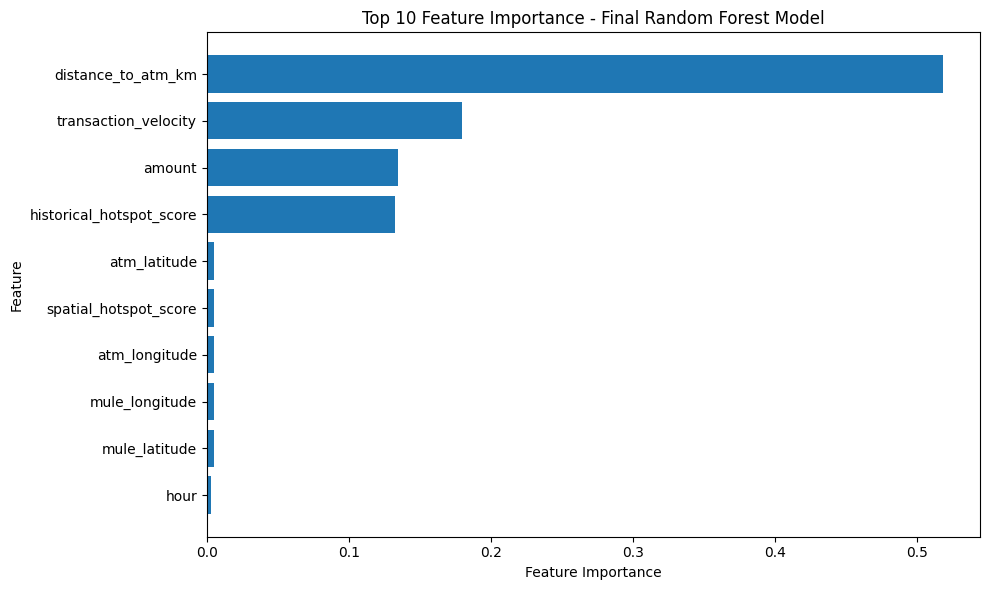


FINAL MODEL INTERPRETATION

The Random Forest primarily uses the highest-ranked features to distinguish cash-out ATM hotspots.

The feature importance results will be used to explain the final hotspot prediction model.

✓ Step 14 completed successfully.


In [ ]:
# ============================================================
# STEP 14: FINAL FEATURE IMPORTANCE / EXPLAINABILITY
# FINAL RANDOM FOREST MODEL
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("FINAL FEATURE IMPORTANCE - RANDOM FOREST")
print("=" * 70)

# ------------------------------------------------------------
# CREATE FEATURE IMPORTANCE TABLE
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Calculate importance percentage
feature_importance["Importance (%)"] = (
    feature_importance["Importance"] * 100
)

# ------------------------------------------------------------
# DISPLAY ALL FEATURES
# ------------------------------------------------------------

print("\nALL FEATURE IMPORTANCE:")
print("-" * 70)

print(feature_importance.to_string(index=False))

# ------------------------------------------------------------
# DISPLAY TOP 10
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP 10 MOST IMPORTANT FEATURES")
print("=" * 70)

print(feature_importance.head(10).to_string(index=False))

# ------------------------------------------------------------
# TOP 4 TOTAL CONTRIBUTION
# ------------------------------------------------------------

top4_importance = feature_importance.head(4)["Importance"].sum()

print("\n" + "=" * 70)
print("TOP 4 FEATURE CONTRIBUTION")
print("=" * 70)

print(f"Combined importance of Top 4 features: {top4_importance:.6f}")
print(f"Percentage contribution: {top4_importance * 100:.2f}%")

print("\nTop 4 features:")
for i, row in feature_importance.head(4).iterrows():
    print(
        f"{i + 1}. {row['Feature']} "
        f"({row['Importance (%)']:.2f}%)"
    )

# ------------------------------------------------------------
# FEATURE IMPORTANCE BAR CHART
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"].head(10)[::-1],
    feature_importance["Importance"].head(10)[::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Final Random Forest Model")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# FINAL INTERPRETATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL MODEL INTERPRETATION")
print("=" * 70)

print(
    "\nThe Random Forest primarily uses the highest-ranked "
    "features to distinguish cash-out ATM hotspots."
)

print(
    "\nThe feature importance results will be used to explain "
    "the final hotspot prediction model."
)

print("\n✓ Step 14 completed successfully.")

In [ ]:
# ============================================================
# FINAL PROJECT SUMMARY - ATM HOTSPOT PREDICTION
# ============================================================

print("=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

print("\n1. PROJECT OBJECTIVE")
print("-" * 70)
print(
    "The objective of this project is to predict cash-out ATM hotspots "
    "using transaction, spatial, historical, and temporal features."
)

print("\n2. DATASET")
print("-" * 70)
print("Total records: 50,000")
print("Training set: 35,000 records")
print("Validation set: 7,500 records")
print("Test set: 7,500 records")

print("\n3. DATA QUALITY CHECKS")
print("-" * 70)
print("Exact duplicate rows: 0")
print("Duplicate feature rows: 0")
print("Conflicting labels: 0")
print("Train-validation feature overlap: 0")
print("Data leakage check: investigated before final model selection")

print("\n4. MODELS EVALUATED")
print("-" * 70)

print("\nLogistic Regression:")
print("Validation Accuracy: 0.815600")
print("Validation F1-Score: 0.803244")
print("Validation ROC-AUC: 0.900601")

print("\nRandom Forest:")
print("Validation Accuracy: 0.999733")
print("Validation F1-Score: 0.999707")
print("Validation ROC-AUC: 1.000000")

print("\nXGBoost:")
print("Validation Accuracy: 0.997733")
print("Validation F1-Score: 0.997515")
print("Validation ROC-AUC: 0.999935")

print("\n5. FINAL MODEL SELECTION")
print("-" * 70)
print("Selected Model: Random Forest")
print("Reason: It achieved the best overall validation performance.")

print("\n6. FINAL UNTOUCHED TEST RESULTS")
print("-" * 70)
print("Accuracy:  0.999333")
print("Precision: 0.999707")
print("Recall:    0.998829")
print("F1-Score:  0.999268")
print("ROC-AUC:   0.999999")
print("Total Errors: 5 out of 7,500 test records")

print("\n7. CROSS-VALIDATION")
print("-" * 70)
print("5-Fold Mean Accuracy: 0.999343")
print("5-Fold Accuracy Std:  0.000390")
print("Minimum Fold Accuracy: 0.998857")
print("Maximum Fold Accuracy: 0.999857")
print("Conclusion: The model showed highly stable performance across folds.")

print("\n8. MOST IMPORTANT FEATURES")
print("-" * 70)
print("1. distance_to_atm_km       - 51.81%")
print("2. transaction_velocity     - 17.96%")
print("3. amount                   - 13.48%")
print("4. historical_hotspot_score - 13.22%")
print("Combined importance of top 4 features: 96.47%")

print("\n9. FINAL CONCLUSION")
print("-" * 70)
print(
    "Random Forest was selected as the final model for cash-out ATM "
    "hotspot prediction. It achieved extremely high and stable performance "
    "on validation, cross-validation, and the untouched test set."
)

print(
    "\nThe most influential feature was distance_to_atm_km, followed by "
    "transaction_velocity, amount, and historical_hotspot_score."
)

print(
    "\nThe very high performance should be interpreted carefully because "
    "the target appears to be strongly determined by a small number of "
    "features and relatively simple decision rules."
)

print("\n" + "=" * 70)
print("PROJECT STATUS: COMPLETED")
print("=" * 70)

FINAL PROJECT SUMMARY

1. PROJECT OBJECTIVE
----------------------------------------------------------------------
The objective of this project is to predict cash-out ATM hotspots using transaction, spatial, historical, and temporal features.

2. DATASET
----------------------------------------------------------------------
Total records: 50,000
Training set: 35,000 records
Validation set: 7,500 records
Test set: 7,500 records

3. DATA QUALITY CHECKS
----------------------------------------------------------------------
Exact duplicate rows: 0
Duplicate feature rows: 0
Conflicting labels: 0
Train-validation feature overlap: 0
Data leakage check: investigated before final model selection

4. MODELS EVALUATED
----------------------------------------------------------------------

Logistic Regression:
Validation Accuracy: 0.815600
Validation F1-Score: 0.803244
Validation ROC-AUC: 0.900601

Random Forest:
Validation Accuracy: 0.999733
Validation F1-Score: 0.999707
Validation ROC-AUC: 1.00

In [ ]:
# Save cleaned dataset
df.to_csv("cleaned_atm_hotspot_data.csv", index=False)

print("Cleaned data saved successfully!")
print("Shape:", df.shape)

Cleaned data saved successfully!
Shape: (50000, 22)


In [ ]:
from google.colab import files

files.download("cleaned_atm_hotspot_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# EXPORT FINAL CLEANED DATASET
# ============================================================

# Check the dataset before saving
print("Cleaned dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

# Save the cleaned dataset
output_file = "cleaned_atm_hotspot_data.csv"

df.to_csv(output_file, index=False)

print("\n✓ Cleaned dataset saved successfully")
print("File name:", output_file)

Cleaned dataset shape: (50000, 22)

Columns:
['timestamp', 'amount', 'mule_latitude', 'mule_longitude', 'atm_latitude', 'atm_longitude', 'distance_to_atm_km', 'transaction_velocity', 'historical_hotspot_score', 'cashout_atm_label', 'hour', 'day', 'day_of_week', 'spatial_hotspot_score', 'month', 'victim_city_Delhi NCR', 'victim_city_Hyderabad', 'victim_city_Jammu', 'victim_city_Jamtara', 'victim_city_Kolkata', 'victim_city_Mewat Nuh', 'victim_city_Mumbai']

✓ Cleaned dataset saved successfully
File name: cleaned_atm_hotspot_data.csv


In [ ]:
import os

file_size = os.path.getsize("cleaned_atm_hotspot_data.csv")

print(
    "File size:",
    round(file_size / (1024 * 1024), 2),
    "MB"
)

File size: 7.55 MB


In [ ]:
from google.colab import files

files.download("cleaned_atm_hotspot_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle

with open("final_random_forest_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("✓ Final Random Forest model saved successfully")

✓ Final Random Forest model saved successfully


In [ ]:
print([x for x in globals() if "rf" in x.lower() or "forest" in x.lower()])

['RandomForestClassifier', 'X_train_rf', 'X_val_rf', 'X_test_rf', 'rf_model', 'y_val_pred_rf', 'y_val_prob_rf', 'rf_model_new', 'rf_no_distance', 'rf_permutation', 'y_train_pred_rf', 'train_accuracy_rf', 'val_accuracy_rf', 'val_precision_rf', 'val_recall_rf', 'val_f1_rf', 'val_auc_rf', 'feature_importance_rf', 'rf_results', 'y_test_pred_rf', 'y_test_prob_rf', 'rf_cv_model']


In [ ]:
import os

files = [
    "cleaned_atm_hotspot_data.csv",
    "final_random_forest_model.pkl"
]

for file in files:
    if os.path.exists(file):
        print(f"✓ {file} exists")
        print(f"  Size: {os.path.getsize(file) / 1024:.2f} KB")
    else:
        print(f"✗ {file} not found")

✓ cleaned_atm_hotspot_data.csv exists
  Size: 7735.08 KB
✓ final_random_forest_model.pkl exists
  Size: 19113.08 KB


In [ ]:
from google.colab import files

files.download("final_random_forest_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>